# Модуль 1. Введение в классический ML

## 5/10   Введение в градиентный спуск


### Упрощенный пример поиска максимума через расчет значения производной для одномерной функции


Исходная функция:

$f(x)=x^{2}-6 * x+5$

Производная по $х$:

$\frac{\partial f}{\partial x}=f^{\prime}(x)=2 * x-6$

Начальное значение минимумума: 45 в точке -4
Финальное значение минимумума: 2.305125096759656e+33 в точке -4.801171832750475e+16


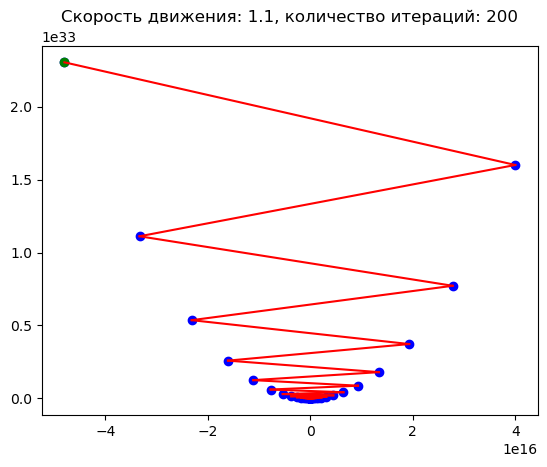

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
  return x*x - 6*x + 5

def dfdx(x):
  return 2*x - 6

N = 200 #количество итераций
lr = 1.1 #скорость оптимизации

fig, ax = plt.subplots()
ax.set_title(f'Скорость движения: {lr}, количество итераций: {N}')

x_plot = np.arange(-5, 11, 0.01)
y_plot = [f(x) for x in x_plot]
ax.plot(x_plot, y_plot)

xc = -4 #начальное значение
print(f'Начальное значение минимумума: {f(xc)} в точке {xc}')

ax.scatter(xc, f(xc), c='r')
for _ in range(N):
  x0 = xc #нужно только для графика

  xc = xc - lr*dfdx(xc) #сам по себе градиентный спуск

  ax.scatter(xc, f(xc), c='b') #нужно только для графика
  ax.plot([x0,xc],[f(x0), f(xc)], c='r') #нужно только для графика

ax.scatter(xc, f(xc), c='g')

print(f'Финальное значение минимумума: {f(xc)} в точке {xc}')

plt.show()

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML  # <--- Важно для отображения

# 1. Функции
def f(x): return x**2 - 6*x + 5
def dfdx(x): return 2*x - 6

# 2. Подготовка данных
x_cur = 0.2
lr = 1.1
steps = 25
history_x = [x_cur]
for _ in range(steps):
    x_cur = x_cur - lr * dfdx(x_cur)
    history_x.append(x_cur)

# 3. Настройка графика
fig, ax = plt.subplots(figsize=(8, 5))
x_axis = np.linspace(-300, 300, 2000)
ax.plot(x_axis, f(x_axis), color='lightgray', zorder=1)
ax.set_ylim(-500, 75000)

dot, = ax.plot([], [], 'ro', label='Спуск', zorder=3)
line, = ax.plot([], [], 'r--', alpha=0.4, zorder=2)
title = ax.set_title('')

# Скрываем создание лишнего статического графика
plt.close() 

# 4. Функция обновления
def update(i):
    curr_x_pts = history_x[:i+1]
    curr_y_pts = [f(x) for x in curr_x_pts]
    
    line.set_data(curr_x_pts, curr_y_pts)
    dot.set_data([history_x[i]], [f(history_x[i])])
    title.set_text(f'Шаг {i}: x = {history_x[i]:.2f}')
    return line, dot

# 5. Создание и отображение
ani = FuncAnimation(fig, update, frames=len(history_x), interval=300, blit=True)

# Самая важная строка для Jupyter:
HTML(ani.to_jshtml())


Начальное значение минимума: 45 в точке -4
Финальное значение минимума: 2.305125096759656e+33 в точке -4.801171832750475e+16


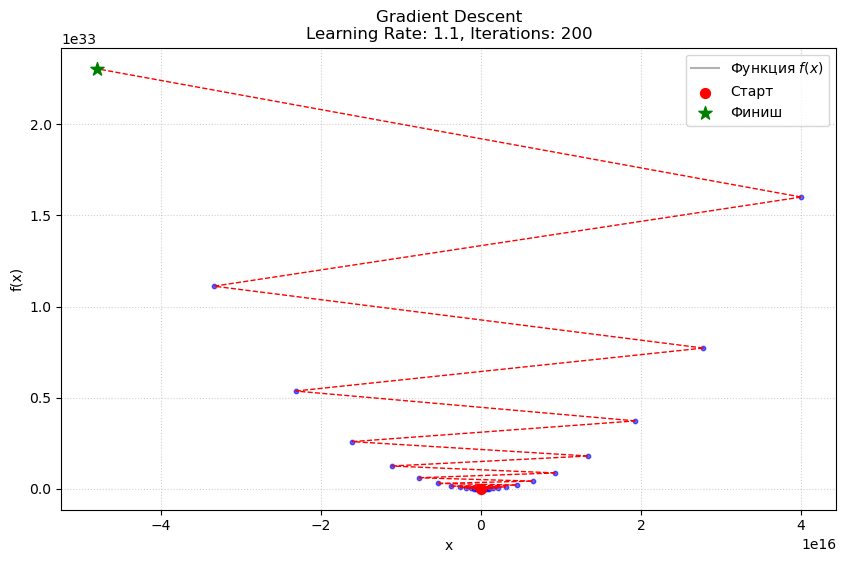

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Создаем "полотно" (fig) и "оси" (ax) для рисования. 
# figsize=(10, 6) задает размер окна в дюймах.
fig, ax = plt.subplots(figsize=(10, 6))

# --- 1. ОТРИСОВКА ГРАФИКА ФУНКЦИИ ---
# Создаем массив чисел от -5 до 11 с шагом 0.01
x_plot = np.arange(-5, 11, 0.01)
# Вычисляем y для каждого x. 
y_plot = [f(x) for x in x_plot]
# Рисуем саму параболу. alpha=0.3 делает её полупрозрачной (фоновой), 
# чтобы она не отвлекала от шагов алгоритма.
ax.plot(x_plot, y_plot, label='Функция $f(x)$', color='black', alpha=0.3)

# --- 2. НАЧАЛЬНАЯ ТОЧКА ---
xc = -4  # Устанавливаем стартовую точку x
print(f'Начальное значение минимума: {f(xc)} в точке {xc}')
# Рисуем большую красную точку 'r' на старте. 
# zorder=5 гарантирует, что точка будет ПОВЕРХ линий.
ax.scatter(xc, f(xc), c='r', s=50, label='Старт', zorder=5)

# --- 3. ЦИКЛ ГРАДИЕНТНОГО СПУСКА ---
for i in range(N):
    x0 = xc  # Сохраняем старый x, чтобы нарисовать линию перехода
    # ГЛАВНАЯ ФОРМУЛА: делаем шаг против градиента
    xc = xc - lr * dfdx(xc)
    
    # Рисуем маленькую синюю точку 'b' в новом положении
    ax.scatter(xc, f(xc), c='b', s=10, alpha=0.6)
    # Рисуем пунктирную красную линию от старого x0 к новому xc
    ax.plot([x0, xc], [f(x0), f(xc)], c='r', linestyle='--', linewidth=1)

# --- 4. ФИНАЛЬНАЯ ТОЧКА ---
# Рисуем большую зеленую звезду 'g' в месте, где алгоритм остановился после N итераций
ax.scatter(xc, f(xc), c='g', s=100, marker='*', label='Финиш', zorder=5)

# --- ОФОРМЛЕНИЕ ---
ax.set_title(f'Gradient Descent\nLearning Rate: {lr}, Iterations: {N}')
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.grid(True, linestyle=':', alpha=0.6) # Легкая сетка
ax.legend() # Вывод легенды (подписи "Старт", "Финиш" и т.д.)

print(f'Финальное значение минимума: {f(xc)} в точке {xc}')

plt.show()


### Создание функции для расчета

In [4]:
def gd(N, lr, min = -5, max = 11, f=f, dfdx=dfdx, xc=-4):
    """
    Реализация и визуализация процедуры градиентного спуска 
    для конкретной функции в упрощенном примере.

    Parameters
    ----------
    N: integer
        Число шагов градиентного спуска, которые необходимо выполнить.
      
    lr: float
        Скорость обучения
    
    min: float
        Минимальное значение, отображаемое на графике
      
    max: float
        Максимальное значение, отображаемое на графике
    
    f: function
        Целевая функция
    
    dfdx: function
        Градиент целевой функции

    Returns
    ----------
    """
    fig, ax = plt.subplots()
    ax.set_title(f'Скорость движения: {lr}, количество итераций: {N}')

    x_plot = np.arange(min, max, 0.01)
    y_plot = [f(x) for x in x_plot]
    ax.plot(x_plot, y_plot)
  
    print(f'Начальное значение минимумума: {f(xc)} в точке {xc}')

    ax.scatter(xc, f(xc), c='r')

    for _ in range(N):
      x0 = xc #нужно только для графика

      xc = xc - lr*dfdx(xc) #сам по себе градиентный спуск

      ax.scatter(xc, f(xc), c='b') #нужно только для графика
      ax.plot([x0,xc],[f(x0), f(xc)], c='r') #нужно только для графика

    ax.scatter(xc, f(xc), c='g')

    print(f'Финальное значение минимумума: {f(xc)} в точке {xc}')
    plt.show()

Начальное значение минимумума: 45 в точке -4
Финальное значение минимумума: 45 в точке -4


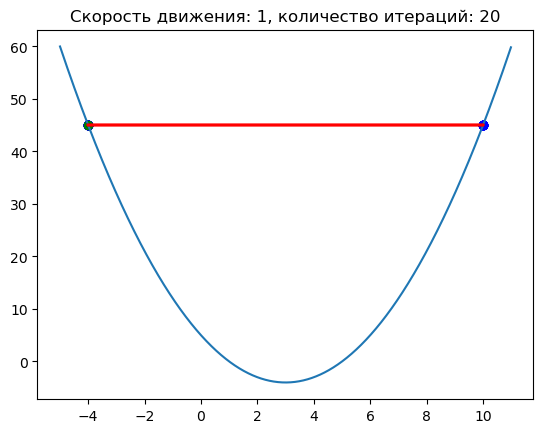

In [5]:
gd(20, 1, min=-5, max = 11)


Начальное значение минимумума: 45 в точке -4
Финальное значение минимумума: -3.9934867828206553 в точке 2.919295494677521


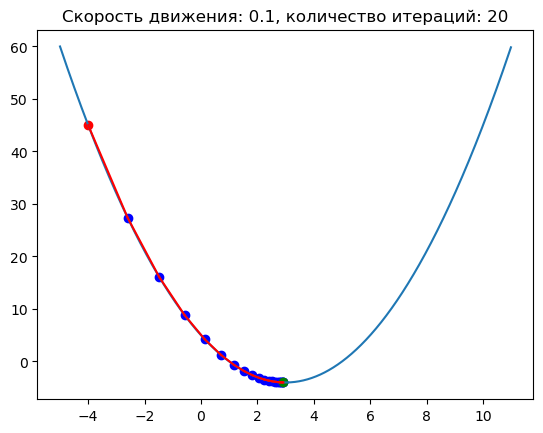

Начальное значение минимумума: 45 в точке -4
Финальное значение минимумума: -3.9999999344992787 в точке 2.9997440689091954


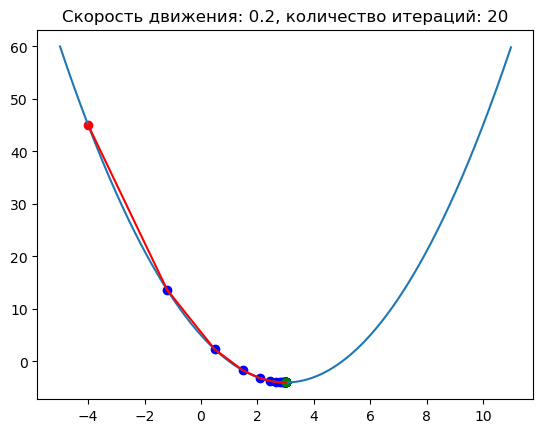

Начальное значение минимумума: 45 в точке -4
Финальное значение минимумума: -3.9999999999999964 в точке 2.999999923034186


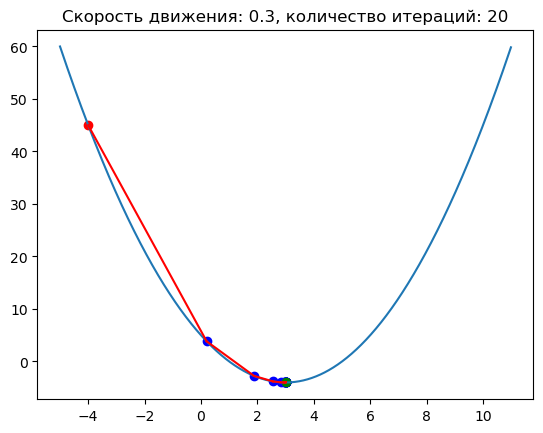

Начальное значение минимумума: 45 в точке -4
Финальное значение минимумума: -4.0 в точке 2.9999999999999267


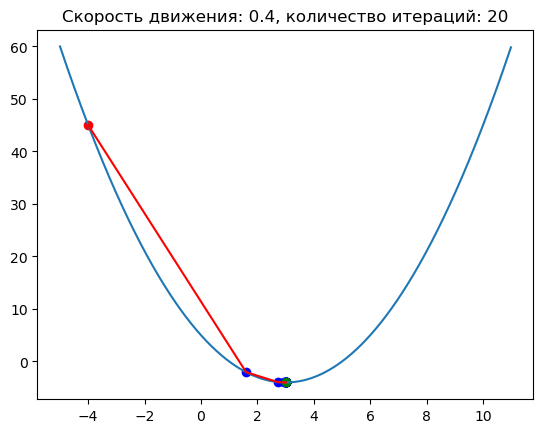

Начальное значение минимумума: 45 в точке -4
Финальное значение минимумума: -4.0 в точке 3.0


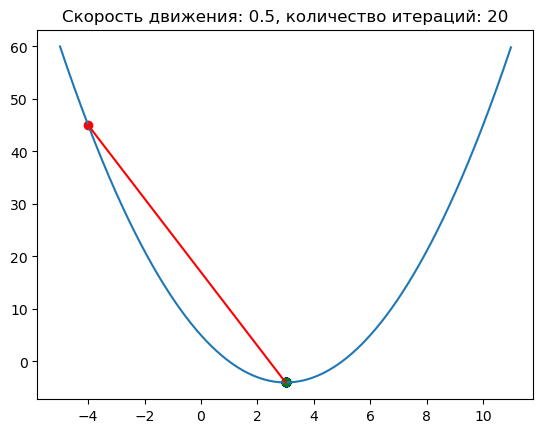

Начальное значение минимумума: 45 в точке -4
Финальное значение минимумума: -4.0 в точке 2.9999999999999267


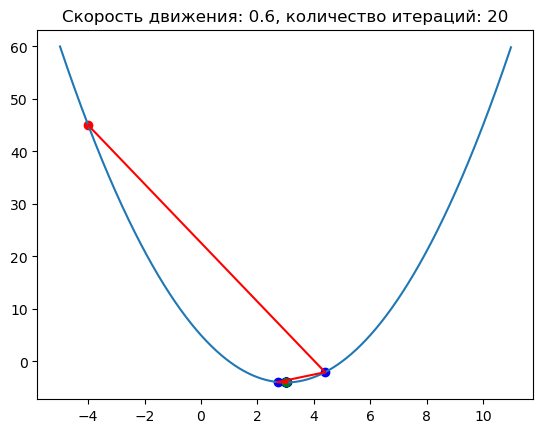

Начальное значение минимумума: 45 в точке -4
Финальное значение минимумума: -3.9999999999999964 в точке 2.999999923034186


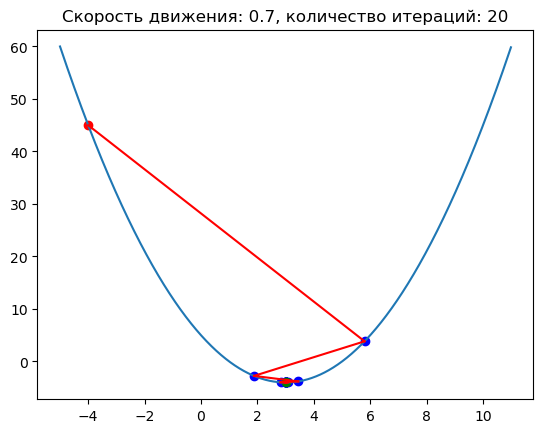

Начальное значение минимумума: 45 в точке -4
Финальное значение минимумума: -3.9999999344992787 в точке 2.9997440689091954


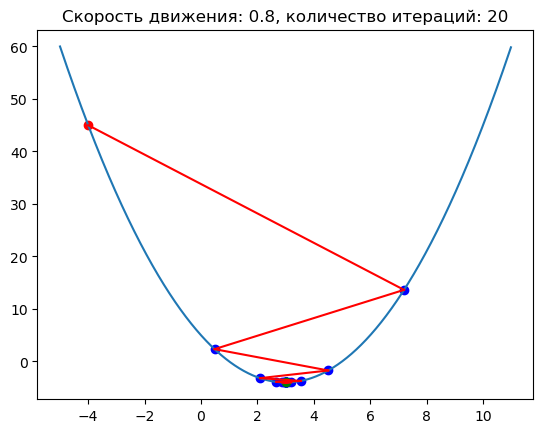

Начальное значение минимумума: 45 в точке -4
Финальное значение минимумума: -3.9934867828206553 в точке 2.9192954946775207


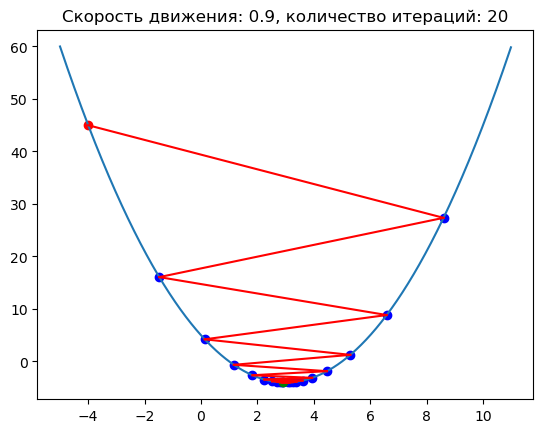

In [6]:
for i in range(1, 10):
  gd(N=20, lr=i/10)

## 6/10   Сложности оптимизации (локальные минимумы)


Рассмотрим более сложную функцию, чем во втором уроке:

$f_{2}(x)=x^{2}+15 * \sin (x)$

$f_{2}^{\prime}(x)=2 * x+15 * \cos (x)$

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def f2(x):
  return x*x + 15*np.sin(x)

def df2dx(x):
  return 2*x + 15*np.cos(x)

Начальное значение минимумума: 91.83968333665945 в точке 10
Финальное значение минимумума: 4.529631081084053 в точке 4.129334334768743


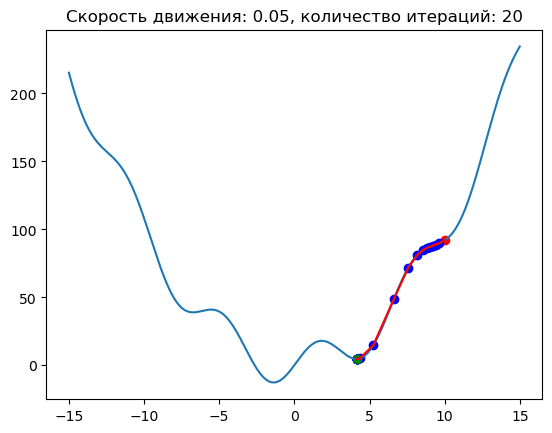

In [8]:
gd(20, 0.05, min=-15, max= 15, f=f2, dfdx=df2dx, xc=10)


Начальное значение минимумума: 39.38386411994708 в точке -5
Финальное значение минимумума: -12.823616841551932 в точке -1.3851303718795267


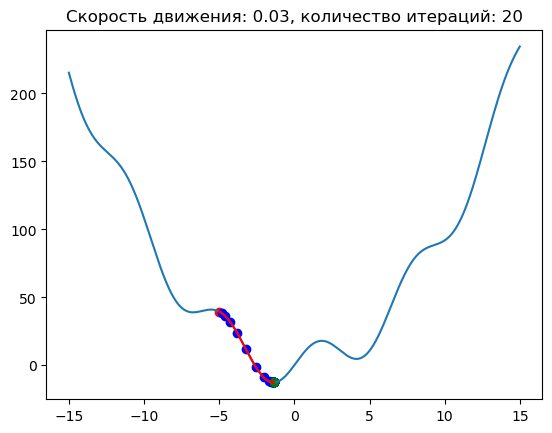

In [9]:
gd(20, 0.03, min=-15, max= 15, f=f2, dfdx=df2dx, xc=-5)


## 8/10   Градиентный спуск в машинном обучении (практическая часть)


In [10]:
from copy import deepcopy # лучший модуль для обеспечения реального копирования объектов
from tqdm import tqdm # библиотека для создания шкалы прогресса итерационного процесса

import seaborn
import numpy as np
import matplotlib.pyplot as plt

Сгенерируем данные $x$ — вектора признаков и $y$ — вектора значений целевой переменной:

In [11]:
std_error = 30 # коэффициент который нужен для генерации случайных данных в разбросе
sample_size = 10000 # размер выборки
theta0, theta1 = 1, 10 # параметры функции, описанной выше

x = np.random.randn(sample_size) # генерация случайной выборки
func_y = lambda x: theta0 + theta1 * x # лямбда-функция для расчета значений функции

y = func_y(x) + std_error * np.random.randn(sample_size) # расчет значений выборки с учетом случайного разброса

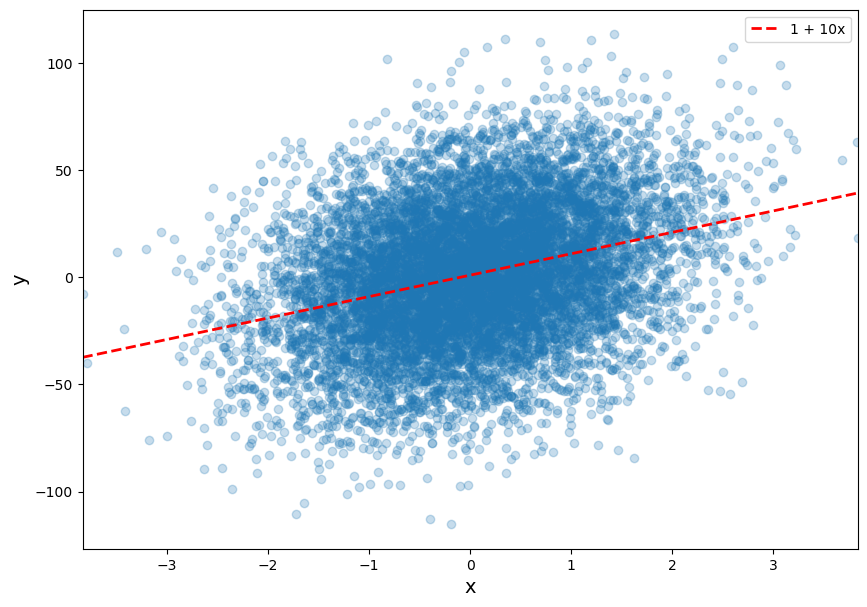

In [12]:
x_plot = np.linspace(x.min(), x.max(), 1000) 
y_plot = func_y(x_plot)

fig = plt.figure(figsize=(10, 7))
plt.scatter(x, y, alpha=0.25)
plt.plot(x_plot, y_plot, "r--", linewidth=2, label=f"{theta0} + {theta1}x")
plt.xlim(x.min(), x.max())
plt.xlabel("x", size=14)
plt.ylabel("y", size=14)
plt.legend(loc="best")

plt.show()

In [13]:
def calculate_predictions(theta0, theta1, X):
    """
    Вычисление значения функции для заданных коэффициентов и значений X.

    Parameters
    ----------
    theta0: float
        Значение параметра theta0.

    theta1: float
        Значение параметра theta1.

    X: array-like, shape = [n_samples, ]
        Вектор признаков.

    Returns
    -------
    y_pred: array-like, shape = [n_samples, ]
        Полученное значение функции.

    """
    return theta0 + theta1*X
    

def calculate_cost(theta0, theta1, X, y):
    """
    Вычисление значения функции потерь.

    Parameters
    ----------
    theta0: float
        Значение параметра theta0.

    theta1: float
        Значение параметра theta1.

    X: array-like, shape = [n_samples, n_features]
        Вектор признаков.

    y: array-like, shape = [n_samples, ]
        Вектор целевой переменной.

    Returns
    -------
    cost: float
        Значение функции потерь.

    """
    theta0 = np.atleast_3d(np.asarray(theta0)) # перевод значений коэффициентов в удобный для работы программы вид
    theta1 = np.atleast_3d(np.asarray(theta1))

    y_pred = calculate_predictions(theta0, theta1, X)
    cost = np.average((y - y_pred)**2, axis=2)/2

    return cost


def gradient_descent_step(theta, X, y, learning_rate):
    """
    Один шаг градиентного спуска.

    Parameters
    ----------
    theta: array-like
        Массив значений параметров theta.

    X: array-like, shape = [n_samples, n_features]
        Вектор признаков.

    y: array-like, shape = [n_samples, ]
        Вектор целевой переменной.

    learning_rate: float
        Скорость обучения.

    Returns
    -------
    updated_theta: array-like
        Обновленный массив значений параметров theta.

    """
    n = len(y)
    y_pred = calculate_predictions(theta[0], theta[1], X)

    updated_theta = deepcopy(theta)
    updated_theta[0] -= learning_rate / n * np.sum((y_pred - y))
    updated_theta[1] -= learning_rate / n * np.sum((y_pred - y) * X)

    return updated_theta

    
def plot_gradient_descent(cost_history, theta_history, X, y):
    """
    Parameters
    ----------
    cost_history: list[float]
        Список со значениями функции потерь на каждой
        итерации обучения.

    theta_history: list[np.array]
        Список двумерных массивов со значением параметров theta.

    X: array-like, shape = [n_samples, n_features]
        Вектор признаков.

    y: array-like, shape = [n_samples, ]
        Вектор целевой переменной.

    """
    fig = plt.figure(figsize=(15, 15))
    plt.subplot(221)
    plt.scatter(range(len(cost_history)), cost_history)
    plt.xlabel("число итераций", size=14)
    plt.ylabel(r"J($\theta$)", size=14)

    plt.subplot(223)
    plt.scatter(x, y, alpha=0.15)
    x_plot = np.linspace(-3, 3, 500)
    for num, theta in enumerate(theta_history):
        y_plot = calculate_predictions(theta[0], theta[1], x_plot)
        if num == 0:
            plt.plot(x_plot, y_plot, color="green", label="Стартовая линия - baseline", linewidth=5)
        if num == len(theta_history) - 1:
            plt.plot(x_plot, y_plot, color="orange", label="Реузльтат работы", linewidth=5)
        else:
            plt.plot(x_plot, y_plot, "r--", alpha=.5)
    plt.xlim(x_plot.min(), x_plot.max())
    plt.xlabel("x", size=14)
    plt.ylabel("y", size=14)
    plt.plot(x_plot, func_y(x_plot), color = "black", label="Исходная линия", linewidth=3)
    plt.legend(loc="best")

    plt.subplot(222)
    x_plot = range(len(cost_history)+1)
    plt.scatter(x_plot, [theta[0] for theta in theta_history], label=r'$\theta_0$')
    plt.scatter(x_plot, [theta[1] for theta in theta_history], label=r'$\theta_1$')
    plt.xlabel("число итераций", size=14)
    plt.ylabel(r"$\theta$", size=14)
    plt.legend(loc="best")
    plt.subplot(224)
    plot_cost_function(X, y, theta_history)


def plot_cost_function(X, y, theta_history):
    """
    Визуализация процесса градиетного спуска и
    построение линий уровня.

    Parameters
    ----------
    X: array-like, shape = [n_samples, n_features]
        Вектор признаков.

    y: array-like, shape = [n_samples, ]
        Вектор целевой переменной.

    theta_history: list[np.array]
        Список двумерных массивов со значением параметров theta.

    """
    theta0 = [theta[0] for theta in theta_history]
    theta1 = [theta[1] for theta in theta_history]

    #theta0_grid = np.linspace(-5*min(theta0), max(theta0), 200)
    #theta1_grid = np.linspace(-5*min(theta1), max(theta1), 200)
    theta0_grid = np.linspace(-25, 25, 200)
    theta1_grid = np.linspace(-25, 25, 200)
    cost_grid = calculate_cost(
        theta0_grid[np.newaxis,:,np.newaxis],
        theta1_grid[:,np.newaxis,np.newaxis],
        X, y
    )
    X, Y = np.meshgrid(theta0_grid, theta1_grid)

    theta0, theta1 = theta_history[-1]
    plt.scatter([theta0]*2, [theta1]*2, s=[50, 0], color=['k','w'])
    contours = plt.contour(X, Y, cost_grid, 30)
    plt.clabel(contours)

    for it in range(1, len(theta_history)):
        plt.annotate(
            '', xy=theta_history[it], xytext=theta_history[it-1],
            arrowprops={'arrowstyle': '->', 'color': 'r', 'lw': 2},
            va='center', ha='center'
        )

    plt.scatter(*zip(*theta_history), color="black", s=40, lw=0)
    plt.xlim(theta0_grid.min(), theta0_grid.max())
    plt.ylim(theta1_grid.min(), theta1_grid.max())
    plt.xlabel(r'$\theta_0$', size=15)
    plt.ylabel(r'$\theta_1$', size=15)
    plt.title('Функция потерь', size=15)

In [14]:
n_iterations, learning_rate = 100, 0.5
theta_history, cost_history = [100*np.random.rand(2)], []

for it in tqdm(range(n_iterations)):
    last_theta = theta_history[-1]
    current_theta = gradient_descent_step(
        theta=last_theta, X=x, y=y, learning_rate=learning_rate
    )
    theta_history.append(current_theta)
    cost_history.append(calculate_cost(current_theta[0], current_theta[1], X=x, y=y))

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 12476.36it/s]


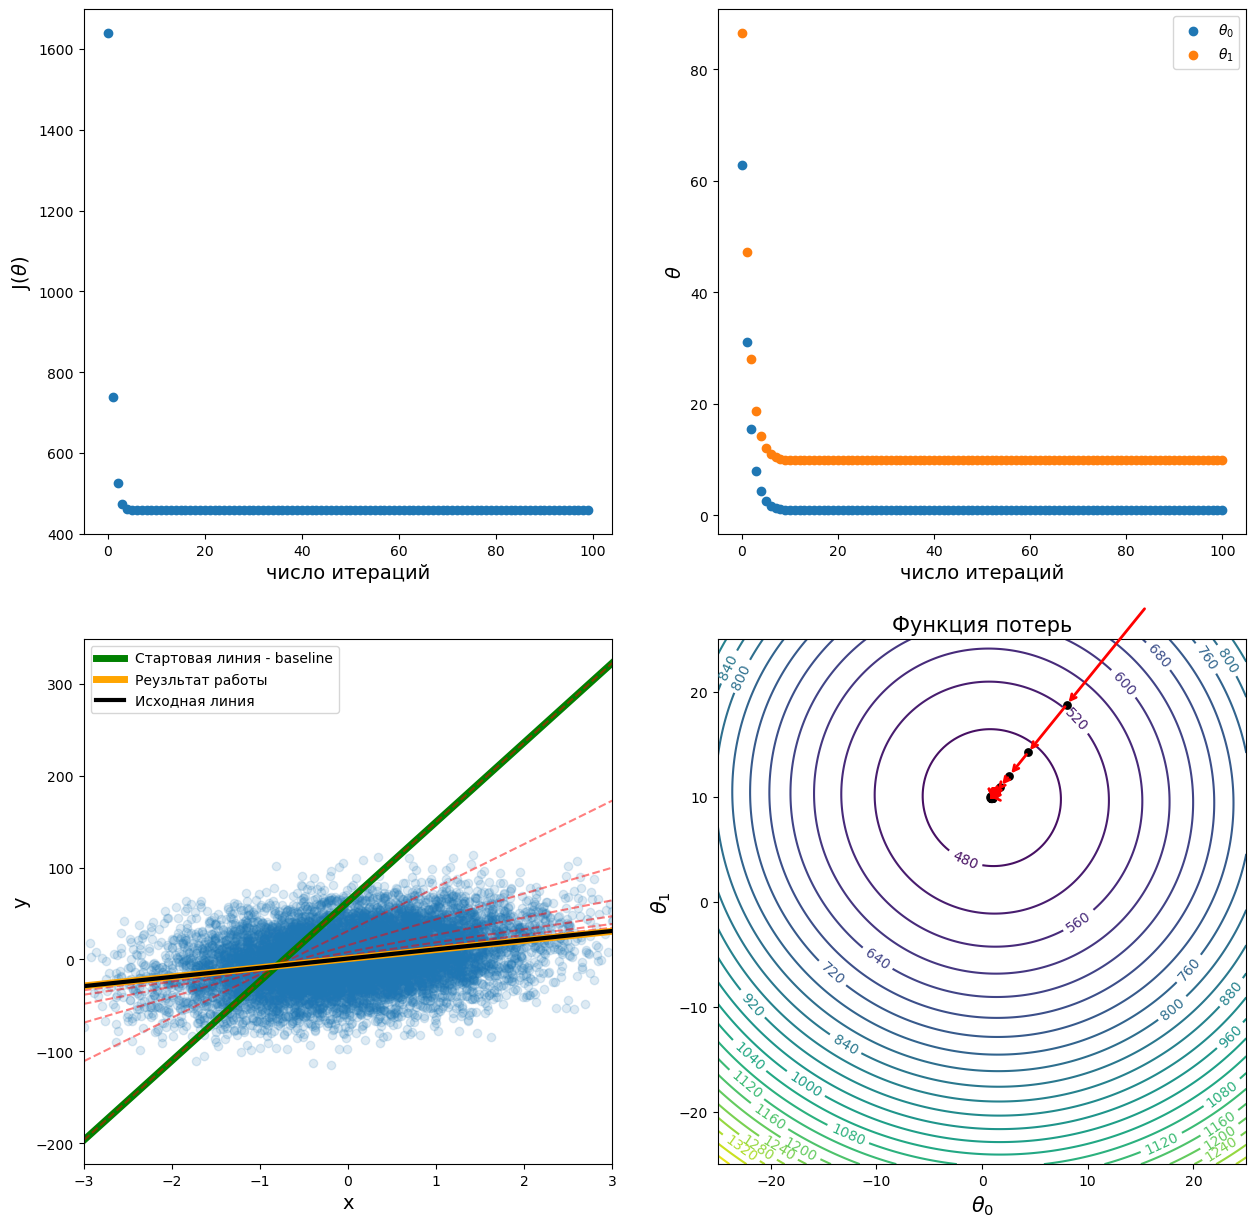

In [15]:
plot_gradient_descent(
    cost_history=cost_history,
    theta_history=theta_history,
    X=x, y=y
)

# Модуль 2. Регрессионные задачи


## 2/11   Задача регрессии

Задача расчёта оптимальных коэффициентов математически может быть записана следующим образом.

$Q(w, x)=\frac{1}{m} \sum_{i=1}^{m}\left(\left\langle w, x_{i}\right\rangle-y_{i}\right)^{2} \rightarrow \min _{w}$

$X=\left(\begin{array}{ccc}x_{11} & \ldots & x_{1 n} \\ \ldots & \ldots & \ldots \\ x_{m 1} & \ldots & x_{m n}\end{array}\right)$ и $\quad y=\left(\begin{array}{c}y_{1} \\ \ldots \\ y_{m}\end{array}\right)$

$Q(w, X)=\frac{1}{m}\|X w-y\|^{2} \rightarrow \min _{w}$

Взяв производную от матрицы и приравняв её к нулю (точка экстремума квадратичной функции), можно получить значения коэффициентов:

$w=\left(X^{T} X\right)^{-1} X^{T} y$

Подробности:
https://habr.com/ru/company/ods/blog/323890/#metod-naimenshih-kvadratov

Теперь напишем код на Python, который аналитически решает задачу выше методами линейной алгебры с использованием библиотеки NumPy:



In [16]:
import numpy as np

def linear_regression_analytical(X, y):
    # Добавляем столбец единичных значений для смещения (bias)
    X_b = np.c_[np.ones((X.shape[0], 1)), X]  
    
    # Вычисление коэффициентов по аналитической формуле
    # w = (X^T X)^-1 X^T y
    theta = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)
    
    return theta

# Пример данных
X = np.array([[1, 2], [2, 5], [3, 7], [4, 10]])  # Матрица признаков
y = np.array([5, 8, 10, 15])  # Целевая переменная

# Нахождение коэффициентов (включая смещение)
theta = linear_regression_analytical(X, y)

print("Коэффициенты модели (включая смещение):")
print(theta)

Коэффициенты модели (включая смещение):
[ 2.5 -2.   2. ]


## 3/11   Задача регрессии (self implementation)


In [17]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

Создадим класс линейной регрессии, который будет содержать ключевые методы для решения задачи — конструктор класса, метод обучения алгоритма, метод пересчета весов и метод, делающий предсказания на основе найденного уравнения:

In [18]:
class LinearRegressionScratch() :

    def __init__(self, learning_rate, iterations) :
        self.lr = learning_rate
        self.iter = iterations
        self.w = None
        self.b = None
        self.loss_history = []

    def fit(self, X, Y) :
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0

        for i in range(self.iter) :
            loss = self.update_weights(X, Y)
            self.loss_history.append(loss)

    def update_weights(self, X, Y) :
        n = X.shape[0]
        preds = X @ self.w + self.b
        e = preds - Y

        # градиент
        dw = 1/n * X.T @ e
        db = 1/n * np.sum(e)

        # обновление весов
        self.w -= self.lr * dw
        self.b -= self.lr * db

        # MSE
        return np.mean(e**2)

    def predict( self, X ) :
        
        return X @ self.w + self.b

In [19]:
import numpy as np

X = np.array([[1], [2], [3], [4]])
y = np.array([3, 5, 7, 9])  # y = 2x + 1

model = LinearRegressionScratch(0.1, 3000)
model.fit(X, y)

print(f'{model.w[0]:.3f} {model.b:.3f}')

2.000 1.000


In [20]:
import numpy as np

X = np.array([[1], [2], [3], [4]])
y = np.array([2, 4, 6, 8])  # y = 2x

model = LinearRegressionScratch(0.1, 3000)
model.fit(X, y)

print(f'{model.w[0]:.3f} {model.b:.3f}')

2.000 0.000


In [21]:
import numpy as np

X = np.array([
    [1, 1],
    [2, 1],
    [3, 1],
    [4, 1]
])
Y = np.array([3, 5, 7, 9])  # y = 2*x1 + 1*x2

model = LinearRegressionScratch(0.1, 2000)
model.fit(X, Y)

print(' '.join(f'{w:.3f}' for w in model.w), f'{model.b:.3f}')

2.000 0.500 0.500


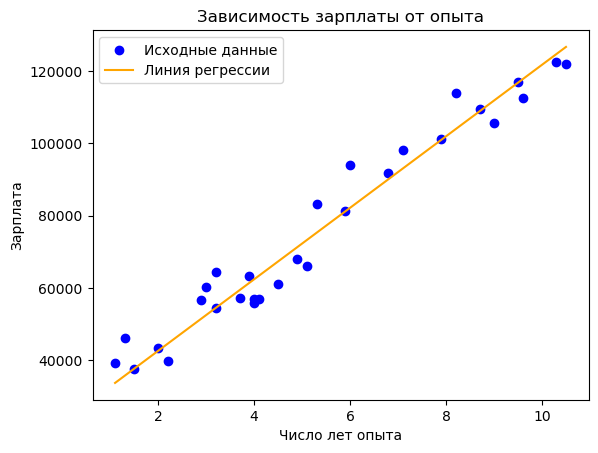

In [22]:
df = pd.read_csv( "salary_data.csv" )

X = df.iloc[:,:-1].values
Y = df.iloc[:,1].values

model = LinearRegressionScratch(iterations = 1000, learning_rate = 0.01)
model.fit(X, Y)

Y_pred = model.predict(X)

plt.scatter(X, Y, color = 'blue', label='Исходные данные')
plt.plot(X, Y_pred, color = 'orange', label='Линия регрессии')
plt.title('Зависимость зарплаты от опыта')
plt.xlabel('Число лет опыта')
plt.ylabel('Зарплата')
plt.legend()

plt.show()

## 4/11   Задача регрессии (sklearn)

In [23]:
import numpy as np 
from sklearn.linear_model import LinearRegression

x = np.array([5, 15, 25, 35, 45, 55]).reshape((-1, 1))
y = np.array([5, 20, 14, 32, 22, 38])

In [24]:
x

array([[ 5],
       [15],
       [25],
       [35],
       [45],
       [55]])

In [25]:
y

array([ 5, 20, 14, 32, 22, 38])

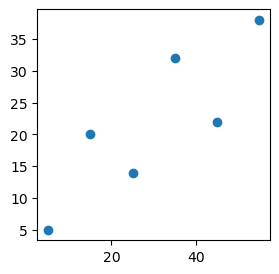

In [26]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(3, 3))
ax.scatter(x, y)
plt.show()

In [27]:
model = LinearRegression()

In [28]:
model.fit(x, y)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [29]:
w0 = model.intercept_
w1 = model.coef_

In [30]:
w0

np.float64(5.633333333333329)

In [31]:
w1

array([0.54])

In [32]:
y_pred = model.predict(x)


In [33]:
y_pred

array([ 8.33333333, 13.73333333, 19.13333333, 24.53333333, 29.93333333,
       35.33333333])

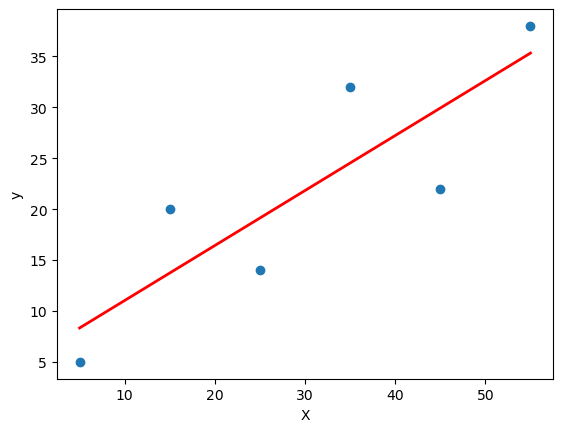

In [34]:
plt.scatter(x, y)
plt.plot(x, y_pred, color='red', linewidth=2)
plt.xlabel('X')
plt.ylabel('y')
plt.show()

Вы также можете проверить полученные результаты аналитическими вычислениями:

In [35]:
X_b = np.c_[np.ones((x.shape[0], 1)), x]
np.linalg.inv(X_b.T@X_b)@X_b.T@y

array([5.63333333, 0.54      ])

## 5/11   Оценка моделей регрессии


**Среднеквадратичная ошибка (Mean Squared Error, MSE)**

$M S E=\frac{1}{m} \sum_{i=0}^{m}\left(y_{i}-\hat{y}_{i}\right)^{2}$

$M A E=\frac{1}{m} \sum_{i=0}^{m}\left|y_{i}-\hat{y}_{i}\right|$

**Коэффициент детерминации**

Коэффициент детерминации, или $R^{2}$, измеряет долю дисперсии целевой переменной, которую модель объясняет. Этот коэффициент варьируется от бесконечности до $1$.

Значение $R^{2}$, близкое к $1$, говорит о том, что модель хорошо объясняет данные, а значение, близкое к $0$, указывает на то, что модель плохо объясняет данные.

$R^{2}=1-\frac{\sum_{i=1}^{m}\left(y_{i}-\hat{y}_{i}\right)^{2}}{\sum_{i=0}^{m}\left(y_{i}-\bar{y}_{i}\right)^{2}}$

Коэффициент $R^{2}$ говорит о том, сколько процентов изменчивости в данных объясняется моделью. Например, если $R^{2}=0.85$, это означает, что 85% изменчивости целевой переменной объясняется моделью.

$R^{2}$ может принимать и отрицательные значения. Если коэффициент детерминации $R^{2}$ принимает отрицательные значения, это указывает на то, что модель регрессии работает хуже, чем тривиальная модель, которая просто предсказывает среднее значение целевой переменной для всех наблюдений.

Вы также можете убедиться, что $R^{2}=0$ в случае, когда вы всегда предсказываете среднее значение.

In [36]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print('Mean Absolute Error:', mean_absolute_error(y, y_pred))
print('Mean Squared Error:', mean_squared_error(y, y_pred))
print('R2 score:', r2_score(y, y_pred))

Mean Absolute Error: 5.466666666666666
Mean Squared Error: 33.75555555555555
R2 score: 0.7158756137479542


## 6/11   Почему алгоритм линейной регрессии — линейный


In [37]:
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt


In [38]:
x = np.array([-4, -3, -2, -1, 0, 1, 2, 3, 4]).reshape((-1, 1))
y = np.array([16, 9, 4, 1, 0, 1, 4, 9, 16])

In [39]:
model = LinearRegression()
model.fit(x, y)
y_pred = model.predict(x)

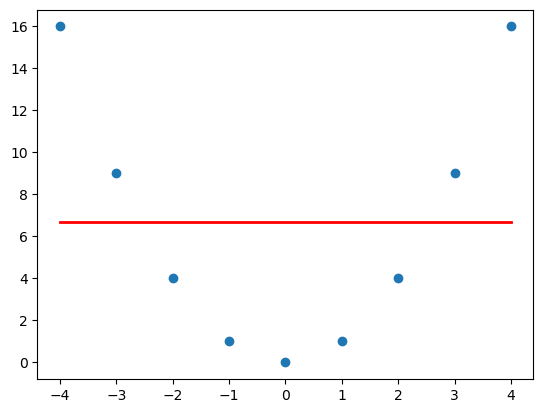

In [40]:
plt.scatter(x, y)
plt.plot(x, y_pred, color='red', linewidth=2);
plt.show()

In [41]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print('Mean Absolute Error:', mean_absolute_error(y, y_pred))
print('Mean Squared Error:', mean_squared_error(y, y_pred))
print('R2 score:', r2_score(y, y_pred))

Mean Absolute Error: 5.185185185185186
Mean Squared Error: 34.22222222222222
R2 score: 0.0


## 7/11   Подготовка данных для обучения. Работа с пропусками в данных

In [42]:
import opendatasets as od
import pandas as pd
import numpy as np
import sys
import os
import kagglehub



In [43]:
# Пробуем скачать через официальную библиотеку
try:
    path = kagglehub.competition_download('house-prices-advanced-regression-techniques')
    print("✅ УСПЕХ! Данные в папке:", path)
except Exception as e:
    print("❌ Ошибка:", e)

✅ УСПЕХ! Данные в папке: /home/itj/.cache/kagglehub/competitions/house-prices-advanced-regression-techniques


In [44]:
sys.version

'3.13.12 | packaged by conda-forge | (main, Feb  5 2026, 05:53:46) [GCC 14.3.0]'

In [45]:
kagglehub.env

<module 'kagglehub.env' from '/home/itj/anaconda3/lib/python3.13/site-packages/kagglehub/env.py'>

In [46]:
help(kagglehub)

Help on package kagglehub:

NAME
    kagglehub

PACKAGE CONTENTS
    auth
    cache
    clients
    colab_cache_resolver
    competition
    config
    datasets
    datasets_enums
    datasets_helpers
    enum
    env
    exceptions
    gcs_upload
    handle
    hf_datasets
    http_resolver
    integrity
    kaggle_cache_resolver
    logger
    models
    models_helpers
    notebooks
    packages
    pandas_datasets
    polars_datasets
    registry
    resolver
    signing
    tracker
    utility_scripts

VERSION
    1.0.0

FILE
    /home/itj/anaconda3/lib/python3.13/site-packages/kagglehub/__init__.py




In [47]:
# Список файлов в папке
print(os.listdir(path))

['sample_submission.csv', 'train.csv', 'data_description.txt', 'test.csv']


In [48]:
# Загрузка данных в DataFrame
train_df = pd.read_csv(f"{path}/train.csv")
test_df = pd.read_csv(f"{path}/test.csv")

In [49]:
train_df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [50]:
train_df.head().T

,0,1,2,3,4
Id,1,2,3,4,5
MSSubClass,60,20,60,70,60
MSZoning,RL,RL,RL,RL,RL
LotFrontage,65.0,80.0,68.0,60.0,84.0
LotArea,8450,9600,11250,9550,14260
...,...,...,...,...,...
MoSold,2,5,9,2,12
YrSold,2008,2007,2008,2006,2008
SaleType,WD,WD,WD,WD,WD
SaleCondition,Normal,Normal,Normal,Abnorml,Normal


In [51]:
df = train_df
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [52]:
df.isna().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

In [53]:
df_nan = df.loc[:, df.isnull().any()]
# посмотрим процент пропущенных значений
df_nan.isnull().sum() / len(df_nan) * 100

LotFrontage     17.739726
Alley           93.767123
MasVnrType      59.726027
MasVnrArea       0.547945
BsmtQual         2.534247
BsmtCond         2.534247
BsmtExposure     2.602740
BsmtFinType1     2.534247
BsmtFinType2     2.602740
Electrical       0.068493
FireplaceQu     47.260274
GarageType       5.547945
GarageYrBlt      5.547945
GarageFinish     5.547945
GarageQual       5.547945
GarageCond       5.547945
PoolQC          99.520548
Fence           80.753425
MiscFeature     96.301370
dtype: float64

In [54]:
df = df.drop(['Alley', 'PoolQC', 'Fence', 'MiscFeature', 'FireplaceQu'], axis = 1)


In [55]:
df["MasVnrArea"] = df["MasVnrArea"].fillna(0)


In [56]:
df['LotFrontage'].describe()

count    1201.000000
mean       70.049958
std        24.284752
min        21.000000
25%        59.000000
50%        69.000000
75%        80.000000
max       313.000000
Name: LotFrontage, dtype: float64

In [57]:
# using median
df['LotFrontage'] = df['LotFrontage'].fillna(df['LotFrontage'].median())

In [58]:
# using mode
df["GarageFinish"] = df["GarageFinish"].fillna(df["GarageFinish"].mode()[0])


In [59]:
df["GarageType"] = df["GarageType"].ffill()
df["Electrical"] = df["Electrical"].bfill()

In [60]:
df["GarageYrBlt"] = df["GarageYrBlt"].interpolate(method="linear", direction = "forward")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 76 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1460 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   LotShape       1460 non-null   str    
 7   LandContour    1460 non-null   str    
 8   Utilities      1460 non-null   str    
 9   LotConfig      1460 non-null   str    
 10  LandSlope      1460 non-null   str    
 11  Neighborhood   1460 non-null   str    
 12  Condition1     1460 non-null   str    
 13  Condition2     1460 non-null   str    
 14  BldgType       1460 non-null   str    
 15  HouseStyle     1460 non-null   str    
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuilt      1460

## 8/11   Подготовка данных для обучения (масштабирование)


Нормализация:

$X_{n o r m}=\frac{X-X_{\min }}{X_{\max }-X_{\min }}$

Стандартизация:

$X_{std} = \frac{X-μ}{σ}$

In [61]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import numpy as np
import pandas as pd

# вектор признаков
X = np.array([[ 1000., -15.,  2.],
              [ 2500.,  10.,  1.],
              [ 3000.,  13., -1.]])

X = pd.DataFrame(X, columns=['f1','f2','f3'])

In [62]:
X

,f1,f2,f3
0,1000.0,-15.0,2.0
1,2500.0,10.0,1.0
2,3000.0,13.0,-1.0


In [63]:
X.mean(axis='rows')

f1    2166.666667
f2       2.666667
f3       0.666667
dtype: float64

In [64]:
X.describe()

,f1,f2,f3
count,3.000000,3.000000,3.000000
mean,2166.666667,2.666667,0.666667
std,1040.833000,15.373137,1.527525
min,1000.000000,-15.000000,-1.000000
25%,1750.000000,-2.500000,0.000000
50%,2500.000000,10.000000,1.000000
75%,2750.000000,11.500000,1.500000
max,3000.000000,13.000000,2.000000


In [65]:
std = StandardScaler()
std.fit(X)

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [66]:
X_std = std.transform(X)
X_std

array([[-1.37281295, -1.40746549,  1.06904497],
       [ 0.39223227,  0.58423096,  0.26726124],
       [ 0.98058068,  0.82323453, -1.33630621]])

Здесь нужно быть аккуратным, так как большинство алгоритмов библиотеки Scikit-learn, несмотря на, то что могут принимать как DataFrame, так и NumPy массивы, возвращают всегда NumPy массив. Поэтому если вы хотите дальше работать с DataFrame, необходимо явным образом его получить.

In [67]:
X_std = pd.DataFrame(X_std, columns=['f1','f2','f3'])
X_std

,f1,f2,f3
0,-1.372813,-1.407465,1.069045
1,0.392232,0.584231,0.267261
2,0.980581,0.823235,-1.336306


In [68]:
X_std.mean(axis='rows').round(0)

f1    0.0
f2    0.0
f3    0.0
dtype: float64

In [69]:
X_std.describe().round(0)

,f1,f2,f3
count,3.0,3.0,3.0
mean,0.0,0.0,0.0
std,1.0,1.0,1.0
min,-1.0,-1.0,-1.0
25%,-0.0,-0.0,-1.0
50%,0.0,1.0,0.0
75%,1.0,1.0,1.0
max,1.0,1.0,1.0


In [70]:
# среднее отклонение по каждому столбцу
X_std.std(axis=0).round()

f1    1.0
f2    1.0
f3    1.0
dtype: float64

In [71]:
mmsc = MinMaxScaler()
X_norm = mmsc.fit_transform(X) # type - numpy array

X_norm = pd.DataFrame(X_norm, columns=['f1','f2','f3'])

In [72]:
X_norm.describe().round(2)

,f1,f2,f3
count,3.00,3.00,3.00
mean,0.58,0.63,0.56
std,0.52,0.55,0.51
min,0.00,0.00,0.00
25%,0.38,0.45,0.33
50%,0.75,0.89,0.67
75%,0.88,0.95,0.83
max,1.00,1.00,1.00


## 9/11   Подготовка данных для обучения. Создание обучающей и валидационной выборок


Обучающая выборка (Training Set) — используется для настройки модели. На её основе алгоритм находит закономерности и обучает параметры модели.

Валидационная выборка (Validation Set) — используется для проверки производительности модели на данных, которые она не видела. Помогает настроить гиперпараметры и выявить переобучение.

Тестовая выборка (Test Set) — применяется для финальной оценки модели после завершения её обучения и настройки.

Стоит заметить, что разделение на подвыборки необходимо только для процесса наиболее оптимального варианта обработки данных, подбора алгоритма ML и дальнейшего обучения. После выбора оптимальной стратегии алгоритм заново обучают на всем наборе данных и отправляют в продакшн.

Также, следует отметить, что все алгоритмы — будь то алгоритмы ML или алгоритмы предобработки данных — обучаются (fit()) на тренировочной подвыборке. На тестовой подвыборке мы лишь применяем (predict()/transform()) обученные алгоритмы, то есть модели.

**Отложенная выборка**


In [73]:
from sklearn.model_selection import train_test_split
import pandas as pd

df = pd.read_csv( "salary_data.csv" )

X = df.iloc[:,:-1].values
y = df.iloc[:,1].values

In [74]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

print(f'Train dataset size: {X_train.shape}, {y_train.shape}')
print(f'Test dataset size: {X_test.shape}, {y_test.shape}')

Train dataset size: (25, 1), (25,)
Test dataset size: (5, 1), (5,)


In [75]:
from sklearn.linear_model import LinearRegression
from sklearn import metrics 

model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("MAE", metrics.mean_absolute_error(y_test, y_pred))
print("MSE", metrics.mean_squared_error(y_test, y_pred))
print("R2 Score:", model.score(X_test, y_test))

MAE 6980.072585105367
MSE 58984671.99168168
R2 Score: 0.869147229126627


**Кроссвалидация**

Используется для обучения и оценки модели машинного обучения с использованием нескольких частей набора данных. Это означает, что вместо того, чтобы разбивать набор данных только на две части, одну для обучения и другую для тестирования, набор данных делится на большее количество подвыборок.

Существует несколько типов кросс-валидации, среди которых:

* K-блочная кросс-валидация (K-fold cross-validation) — здесь датасет делится на K равных частей (блоков), один из блоков используется для валидации, остальные – для обучения. Процесс повторяется K раз, каждый раз — с новым блоком для валидации.
* Стратифицированная K-блочная кросс-валидация (Stratified K-fold cross-validation) — аналогично K-блочной кросс-валидации, но с учетом пропорции классов в каждом блоке. Используется в случае несбалансированных данных.
* Оставить-P-выборок (Leave-P-Out cross-validation) — здесь на каждой итерации из датасета удаляется P объектов для валидации, остальные используются для обучения. Процесс повторяется для всех возможных комбинаций выборок размера P.

Значение k должно быть тщательно выбрано для выборки данных. Плохо выбранное значение для k может привести к неправильному представлению о качестве модели — например, к оценке с высокой дисперсией (которая может сильно измениться на основе данных, используемых в соответствии с моделью) или к высокой предвзятости (например, переоценка качества модели).

k выбирают обычно 5 или 10, но нет формального правила. По мере того, как k становится больше, разница в размере между тестовой выборкой и подмножествами resampling становится мала. По мере уменьшения этой разницы предвзятость к технике становится меньше.

In [76]:
from sklearn.model_selection import KFold, cross_val_score

# Define the number of folds for cross-validation
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

In [77]:
lin_reg = LinearRegression()

scores = cross_val_score(lin_reg, X, y, cv=kf, scoring='r2')
print(scores)

[0.90244618 0.96846325 0.91621488 0.98161851 0.84333552]


Как интерпретировать результат:
* Чем более похожи оценки между собой, тем стабильнее и лучше работает модель.
* Если вы видите, что по какому-то из разбиений получилась метрика, сильно отличающаяся от остальных, это говорит о том, что есть некоторые закономерности/особенности в данных, которые модель плохо распознает. В этом случае надо вернуться на несколько шагов назад и попробовать другие способы предобработки данных/параметры алгоритма ML или другой алгоритм в принципе.

In [78]:
scores.mean()

np.float64(0.9224156654035129)

# Модуль 3. Задачи классификации

## 2/10 Теория

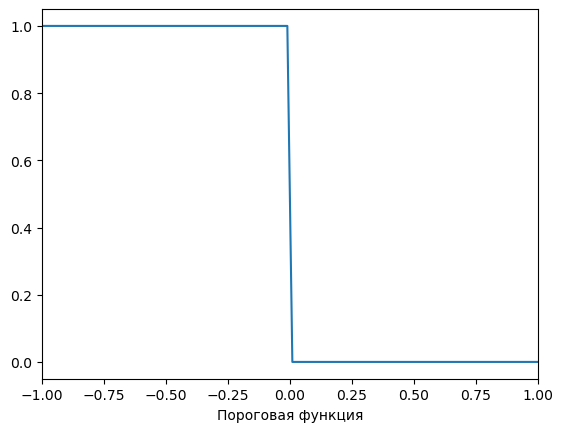

In [79]:
import matplotlib.pyplot as plt
import numpy as np

def loss_function(x):
    return 0 if x > 0 else 1
data = np.linspace(-1, 1, 100)
loss = [loss_function(x) for x in data]

plt.xlabel('Пороговая функция')
plt.xlim(-1, 1)
plt.plot(data, loss)
plt.show()

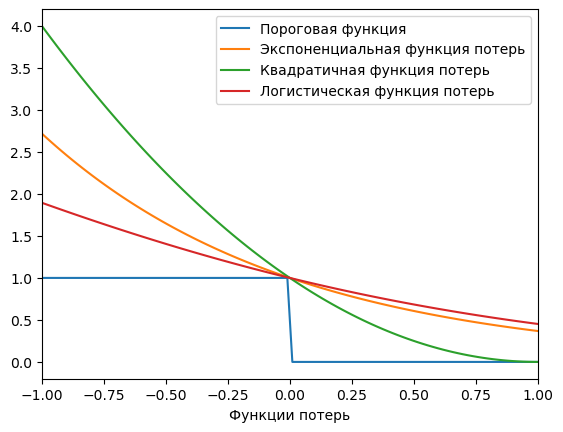

In [80]:
def exp_loss_func(x):
    return np.exp(-x)

def square_loss(x):
    return (1 - x) ** 2

def logistic_loss(x):
    return np.log2(1 + np.exp(-x))

exp_loss = [exp_loss_func(x) for x in data]
logistic_loss = [logistic_loss(x) for x in data]
square_loss = [square_loss(x) for x in data]

plt.xlabel('Функции потерь')
plt.xlim(-1, 1)
plt.plot(data, loss)
plt.plot(data, exp_loss)
plt.plot(data, square_loss)
plt.plot(data, logistic_loss)
plt.legend(['Пороговая функция', 'Экспоненциальная функция потерь', 'Квадратичная функция потерь', 'Логистическая функция потерь'])
plt.show()

## 3/10   Задача классификации (логистическая регрессия)


Логистическая регрессия — это частный случай линейного классификатора. Она обладает одной полезной особенностью — помимо отнесения объекта к определенному классу умеет прогнозировать вероятность $P$ того, что объект относится к этому классу.

Однако логистическая регрессия вовсе не регрессия по своей природе, а классификатор — не перепутайте.

В модели логистической регрессии в качестве такой функции берется сигмоида, которая имеет вид:

$\sigma(z)=\frac{1}{1+\exp (-z)}$

In [81]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

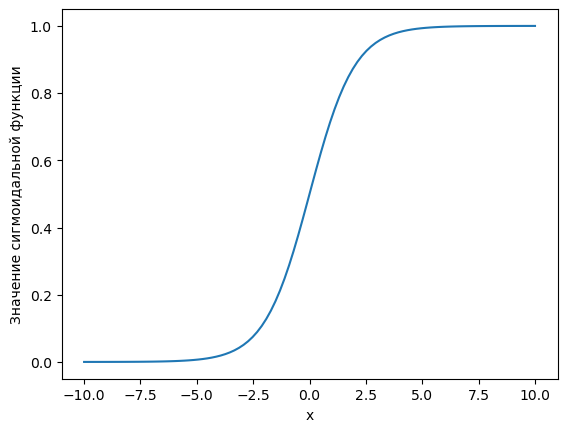

In [82]:
data = np.linspace(-10, 10, 100)
sigmoid_value = list(map(sigmoid, data))

plt.xlabel('x')
plt.ylabel('Значение сигмоидальной функции')
plt.plot(data, sigmoid_value)
plt.show()

$P(y=1 \mid x)$,  для краткости обозначим $p+$, будет равняться

$p_{+}=\frac{1}{1+\exp \left(-\left\langle w, x_{i}\right\rangle\right)}$

Чем больше будет скалярное произведение $\left\langle w, x_{i}\right\rangle$, тем выше окажется предсказанная вероятность.

При этом мы знаем как рассчитать скалярное произведение, но не знаем, как рассчитать вероятность. Выведем необходимые значения:

$\left\langle w, x_{i}\right\rangle=\ln \frac{p_{+}}{1-p_{+}}$

Выражение под логарифмом называется риском (отношение вероятности положительного события к, по сути, вероятности отрицательного события), а вместе с логарифмом это выражение называется логитом. Поэтому метод и называется логистической регрессией: мы приближаем логит линейной комбинацией признаков и весов.

Для обучения этой модели (а точнее, подбора расчетной функции, которую можно использовать для обучения) нам потребуется использовать метод максимального правдоподобия. Он заключается в выборе гипотезы, при которой вероятность получить имеющееся наблюдение максимальна.

С точки зрения реализуемого алгоритма вероятность того, что в выборке встретится объект $x_{i}$ c классом $y_{i}$, равна:

$P\left(y=y_{i} \mid x_{i}\right)=p_{+}^{\left[y_{i}=+1\right]}\left(1-p_{+}\right)^{\left[y_{i}=-1\right]}$


Для всей выборки это значение будет равно произведению ее элементов:

$P(y \mid X)=L(X)=\prod_{i=1}^{l} p_{+}^{\left[y_{i}=+1\right]}\left(1-p_{+}\right)^{\left[y_{i}=-1\right]}$

Проблема произведения в том, что его крайне тяжело оптимизировать. Для решения проблемы произведения рационально использовать логарифмирование:

$-\ln L(X)=-\sum_{i=1}^{l}\left(\left[y_{i}=+1\right] \ln p_{+}+\left[y_{i}=-1\right] \ln \left(1-p_{+}\right)\right)$

Эта функция потерь называется логарифмической функцией потерь (log loss), или кросс-энтропией.

Обратите внимание на знак «-» перед логарифмом. Он необходим для того, чтобы перейти от задачи «максимального» правдоподобия к задаче «минимального».

Когда $y$ принимает значения $0$ и $1$, log loss пишется как:

$\begin{aligned}
& -\ln L(X)=-\sum_{i=1}^{l}\left(y_{i} \ln \frac{1}{1+\exp \left(-\left\langle w, x_{i}\right\rangle\right)}+\left(1-y_{i}\right) \ln \left(1-\frac{1}{1+\exp \left(-\left\langle w, x_{i}\right\rangle\right)}\right)\right) \\
& -\ln L(X)=-\sum_{i=1}^{l}\left(y_{i} \ln (\sigma)+\left(1-y_{i}\right) \ln (1-\sigma)\right)
\end{aligned}$

## 4/10   Логистическая регрессия (self implementation)


### self implementation

In [83]:
import numpy as np

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def log_loss(w, b, X, y):
    z = X @ w + b
    y_pred = sigmoid(z)
    
    # Добавляем epsilon, чтобы избежать Nan при log(0)
    eps = 1e-15
    # Теперь предсказания будут больше ноля и меньше единицы
    y_pred = np.clip(y_pred, eps, 1 - eps)
    
    loss = -np.mean(y * np.log(y_pred) + (1 - y) * np.log(1 - y_pred))

    grad_w = (X.T @ (y_pred - y)) / X.shape[0]
    grad_b = np.mean(y_pred - y)

    return loss, grad_w, grad_b

def optimize(w, b, X, y, n_iterations, eta):
    losses = []

    for i in range(n_iterations):
        loss, grad_w, grad_b = log_loss(w, b, X, y)
        w -= eta * grad_w
        b -= eta * grad_b
        losses.append(loss)

    return w, b, losses

def predict(w, b, X, p=0.5):
    # Используем матричное умножение (это быстрее циклов)
    z = X @ w + b
    y_proba = sigmoid(z)
    
    # Превращаем вероятности в 0 или 1 по порогу p
    return (y_proba >= p).astype(int)

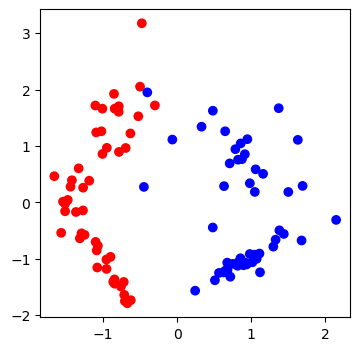

Размер массива признаков обучающей выборки (70, 2)
Размер массива признаков тестовой выборки (30, 2)
Размер массива ответов для обучающей выборки (70,)
Размер массива ответов для тестовой выборки (30,)
Итоговый вектор весов w: [3.76368713 0.22385252]
Точность на обучающей выборке: 98.571
Точность на тестовой выборке: 96.667


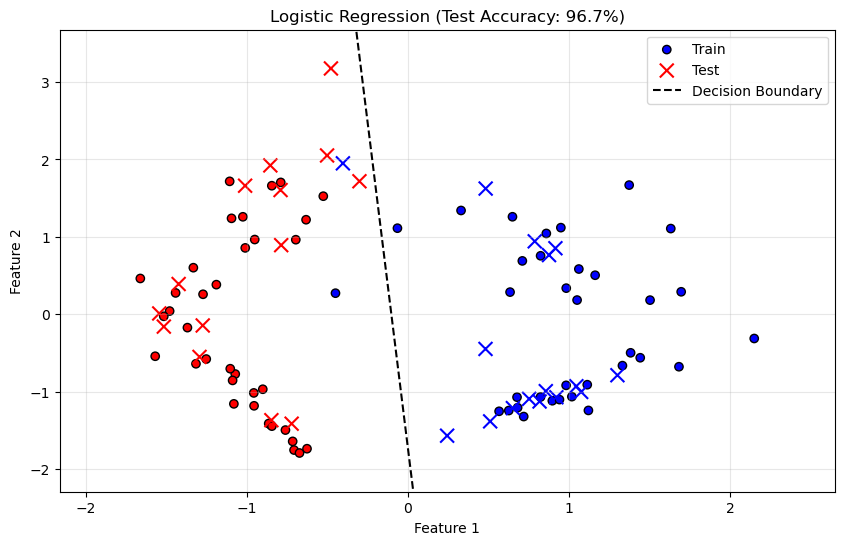

In [84]:
from sklearn import datasets
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt

# сгеренируем данные
classes = datasets.make_classification(n_samples=100, n_features=2, n_informative=2, n_redundant=0, n_classes=2, random_state=1)

# и изобразим их на графике
colors = ListedColormap(['red', 'blue'])

plt.figure(figsize=(4, 4))
plt.scatter([x[0] for x in classes[0]], [x[1] for x in classes[0]], c=classes[1], cmap=colors)
plt.show()

# перемешивание датасета
np.random.seed(12) # это число позволяет постоянно получать одну и ту же "случайность"
shuffle_index = np.random.permutation(classes[0].shape[0])
X_shuffled, y_shuffled = classes[0][shuffle_index], classes[1][shuffle_index]

# разбивка на обучающую и тестовую выборки
train_proportion = 0.7
train_test_cut = int(len(classes[0]) * train_proportion)

X_train, X_test, y_train, y_test = \
    X_shuffled[:train_test_cut], \
    X_shuffled[train_test_cut:], \
    y_shuffled[:train_test_cut], \
    y_shuffled[train_test_cut:]

print("Размер массива признаков обучающей выборки", X_train.shape)
print("Размер массива признаков тестовой выборки", X_test.shape)
print("Размер массива ответов для обучающей выборки", y_train.shape)
print("Размер массива ответов для тестовой выборки", y_test.shape)


# Далее транспонируем матрицы данных, так как нам удобнее работать со строками:

# X_train_tr = X_train.transpose()
# y_train_tr = y_train.reshape(1, y_train.shape[0])
# X_test_tr = X_test.transpose()
# y_test_tr = y_test.reshape(1, y_test.shape[0])


# инициализируем начальные веса
n_features = X_train.shape[1]
w0 = np.zeros(n_features)
b0 = 0.0

n_iterations = 1000
eta = 0.05

w, b, losses = optimize(w0, b0, X_train, y_train, n_iterations, eta)

y_predicted_train = predict(w, b, X_train)
y_predicted_test = predict(w, b, X_test)

# В качестве меры точности возьмем долю правильных ответов
train_accuracy = np.mean(y_predicted_train == y_train) * 100
test_accuracy = np.mean(y_predicted_test == y_test) * 100

print(f"Итоговый вектор весов w: {w}")
print(f"Точность на обучающей выборке: {train_accuracy:.3f}")
print(f"Точность на тестовой выборке: {test_accuracy:.3f}")

# Визуализация результата
plt.figure(figsize=(10, 6))

# 1. Рисуем данные
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=colors, label='Train', edgecolors='k')
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap=colors, marker='x', s=100, label='Test')

# 2. Расчет разделяющей прямой
# Формула: w0*x + w1*y + b = 0  =>  y = -(w0*x + b) / w1
x_min, x_max = X_shuffled[:, 0].min() - 0.5, X_shuffled[:, 0].max() + 0.5
x_values = np.array([x_min, x_max])
y_values = -(w[0] * x_values + b) / w[1]  # Используем индексы [0] и [1]

# 3. Настройка отображения
plt.plot(x_values, y_values, "k--", label="Decision Boundary")

# Ограничиваем оси по реальным границам данных, чтобы график не «сплющивало»
plt.ylim(X_shuffled[:, 1].min() - 0.5, X_shuffled[:, 1].max() + 0.5)
plt.xlim(x_min, x_max)

plt.title(f"Logistic Regression (Test Accuracy: {test_accuracy:.1f}%)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

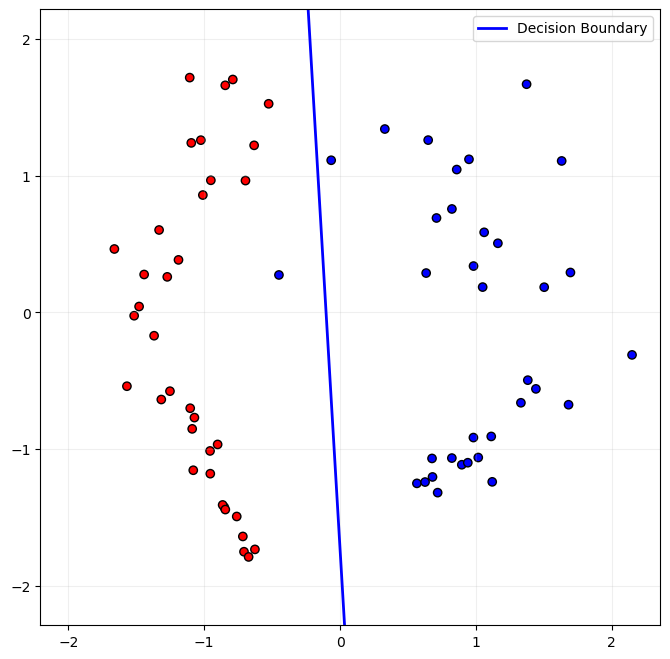

In [85]:
data = np.linspace(-2, 2, 100)

plt.figure(figsize=(8, 8))

# 1. Рисуем точки
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=colors, edgecolors='k')

# 2. СЧИТАЕМ ПРАВИЛЬНУЮ ЛИНИЮ
# Используем формулу: x2 = -(w1*x1 + b) / w2
# w[0] — это w1, w[1] — это w2
line_values = -(w[0] * data + b) / w[1]

# 3. Рисуем линию
plt.plot(data, line_values, label='Decision Boundary', color='blue', linewidth=2)

# Ограничиваем оси, чтобы график был аккуратным
plt.ylim(X_train[:, 1].min() - 0.5, X_train[:, 1].max() + 0.5)
plt.grid(True, alpha=0.2)
plt.legend()
plt.show()


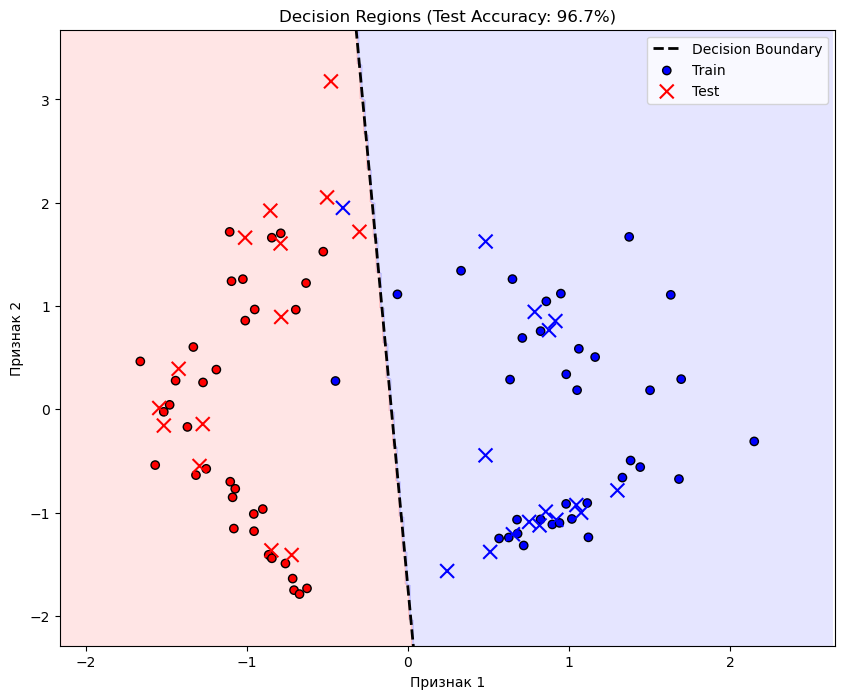

In [86]:
# 1. Создаем сетку (meshgrid) для закрашивания фона
h = .02  # шаг сетки
x_min, x_max = X_shuffled[:, 0].min() - 0.5, X_shuffled[:, 0].max() + 0.5
y_min, y_max = X_shuffled[:, 1].min() - 0.5, X_shuffled[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# 2. Получаем предсказания для каждой точки сетки
# Раскладываем сетку в один длинный список пар координат и прогоняем через predict
grid_points = np.c_[xx.ravel(), yy.ravel()]
Z = predict(w, b, grid_points)
Z = Z.reshape(xx.shape)

# 3. Визуализация
plt.figure(figsize=(10, 8))

# Рисуем области (светлые цвета фона)
from matplotlib.colors import ListedColormap
background_colors = ListedColormap(['#FFAAAA', '#AAAAFF']) # Светло-красный и светло-синий
plt.contourf(xx, yy, Z, cmap=background_colors, alpha=0.3)

# Рисуем разделяющую прямую (черный пунктир)
x_line = np.array([x_min, x_max])
y_line = -(w[0] * x_line + b) / w[1]
plt.plot(x_line, y_line, "k--", lw=2, label="Decision Boundary")

# Рисуем обучающие (кружки) и тестовые (крестики) данные
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=colors, edgecolors='k', label='Train')
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap=colors, marker='x', s=100, label='Test')

plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.title(f"Decision Regions (Test Accuracy: {test_accuracy:.1f}%)")
plt.xlabel("Признак 1")
plt.ylabel("Признак 2")
plt.legend()
plt.show()


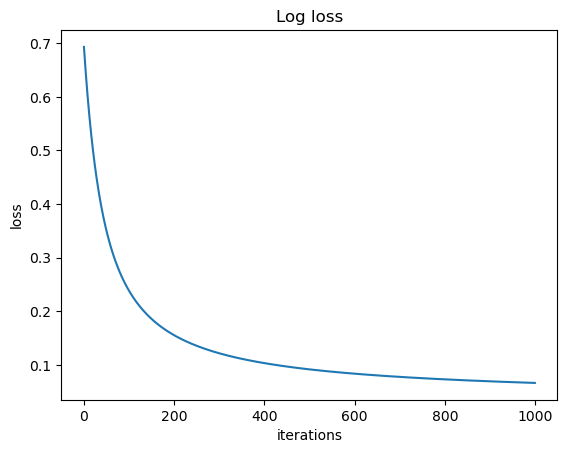

In [87]:
plt.title('Log loss')
plt.xlabel('iterations')
plt.ylabel('loss')
plt.plot(range(len(losses)), losses)

plt.show()

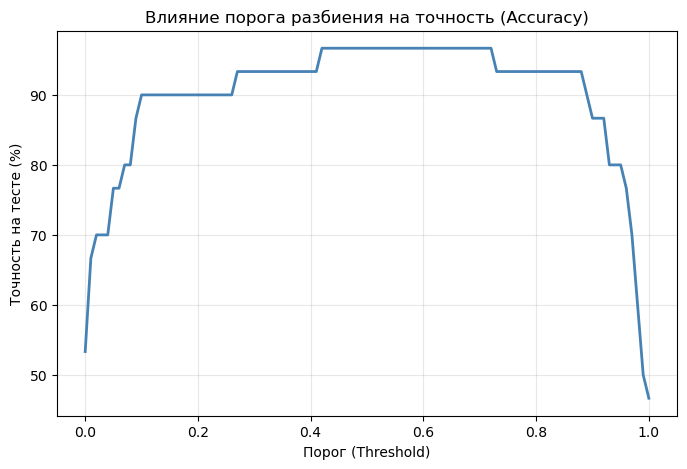

In [88]:
thresholds = []
test_accs = []

# Используем np.linspace для красоты или оставляем range
for p in np.linspace(0, 1, 101):
    # ВАЖНО: передаем w, b (из обучения), X_test и явно указываем p
    y_predicted_test = predict(w, b, X_test, p)
    
    # Считаем точность (простой и понятный способ)
    accuracy = np.mean(y_predicted_test == y_test) * 100
    
    thresholds.append(p)
    test_accs.append(accuracy)

# Отрисовка
plt.figure(figsize=(8, 5))
plt.plot(thresholds, test_accs, color='steelblue', linewidth=2)
plt.title("Влияние порога разбиения на точность (Accuracy)")
plt.xlabel("Порог (Threshold)")
plt.ylabel("Точность на тесте (%)")
plt.grid(True, alpha=0.3)
plt.show()


### тесты с яндекс контест

In [89]:
import numpy as np

X = np.array([[0], [1]])
y = np.array([0, 1])

w = np.zeros(X.shape[1])
b = 0.0

w, b, _ = optimize(w, b, X, y, n_iterations=5000, eta=0.5)
y_pred = predict(w, b, X)

print(*y_pred)

0 1


In [90]:
import numpy as np

X = np.array([[1], [2], [3], [4]])
y = np.array([0, 0, 1, 1])

w = np.zeros(X.shape[1])
b = 0.0

w, b, _ = optimize(w, b, X, y, n_iterations=5000, eta=0.5)
y_pred = predict(w, b, X)

print(*y_pred)

0 0 1 1


In [91]:
import numpy as np

X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])
y = np.array([0, 0, 0, 1])

w = np.zeros(X.shape[1])
b = 0.0

w, b, _ = optimize(w, b, X, y, n_iterations=5000, eta=0.5)
y_pred = predict(w, b, X)

print(*y_pred)

0 0 0 1


In [92]:
y

array([0, 0, 0, 1])

In [93]:
y_pred

array([0, 0, 0, 1])

In [94]:
X

array([[0, 0],
       [0, 1],
       [1, 0],
       [1, 1]])

### gemini adds

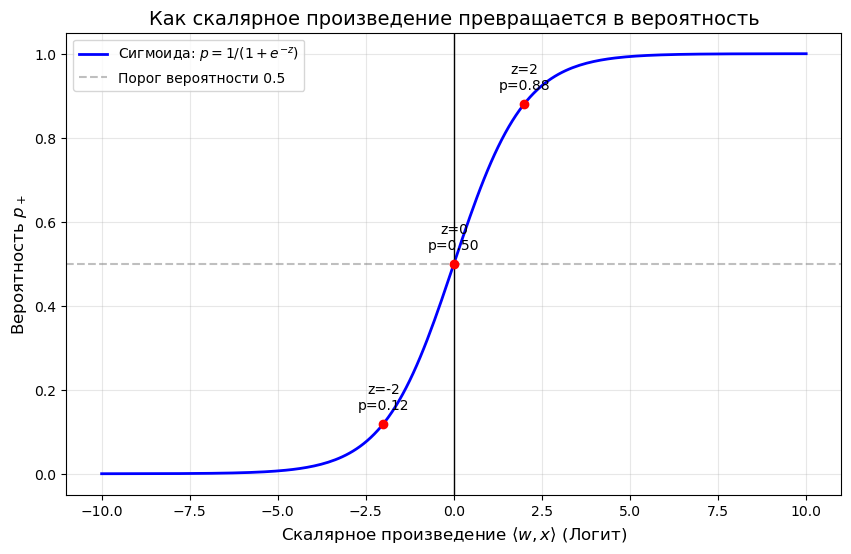

In [95]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Определим функцию сигмоиды
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# 2. Создадим диапазон значений скалярного произведения (от -10 до 10)
# Это те самые значения <w, x>, которые выдает линейная часть модели
z = np.linspace(-10, 10, 200)
p = sigmoid(z)

# 3. Визуализация
plt.figure(figsize=(10, 6))
plt.plot(z, p, label='Сигмоида: $p = 1 / (1 + e^{-z})$', color='blue', lw=2)

# Добавим важные линии
plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Порог вероятности 0.5')
plt.axvline(x=0, color='black', lw=1)

# Подсветим точки для примера
points_to_show = [-2, 0, 2]
for p_z in points_to_show:
    prob = sigmoid(p_z)
    plt.scatter(p_z, prob, color='red', zorder=5)
    plt.annotate(f'z={p_z}\np={prob:.2f}', (p_z, prob), 
                 textcoords="offset points", xytext=(0,10), ha='center')

# Оформление
plt.title('Как скалярное произведение превращается в вероятность', fontsize=14)
plt.xlabel('Скалярное произведение $\langle w, x \\rangle$ (Логит)', fontsize=12)
plt.ylabel('Вероятность $p_+$', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


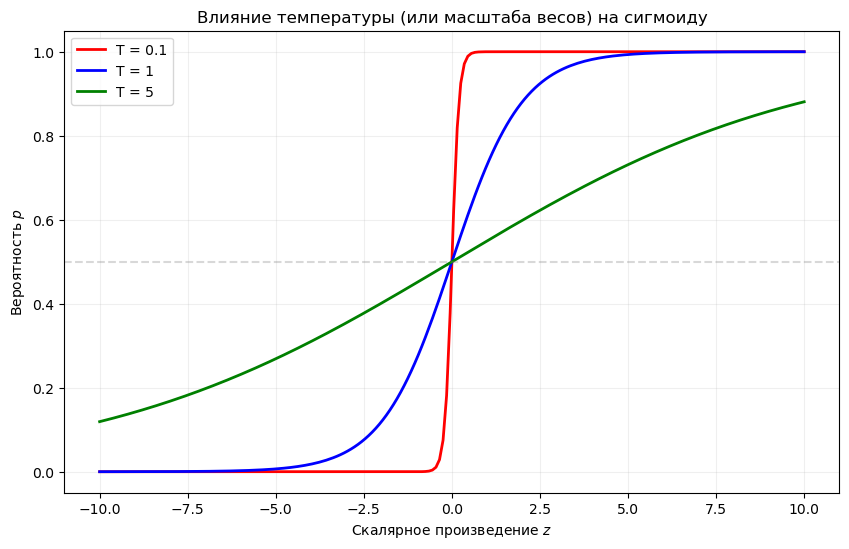

In [96]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid_temp(z, T):
    return 1 / (1 + np.exp(-z / T))

z = np.linspace(-10, 10, 200)

plt.figure(figsize=(10, 6))

# Разные значения T
# Маленькое T — модель очень резкая (уверенная)
# Большое T — модель очень мягкая (неуверенная)
temperatures = [0.1, 1, 5]
colors = ['red', 'blue', 'green']

for T, color in zip(temperatures, colors):
    p = sigmoid_temp(z, T)
    plt.plot(z, p, label=f'T = {T}', color=color, lw=2)

plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.3)
plt.title('Влияние температуры (или масштаба весов) на сигмоиду')
plt.xlabel('Скалярное произведение $z$')
plt.ylabel('Вероятность $p$')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()


## 5/10   Работа с категориальными переменными


### Dataset Students Performance

Давайте для примера рассмотрим открытый набор данных с платформы Kaggle:

https://www.kaggle.com/datasets/allexanderspb/studentsperformance


In [97]:
import pandas as pd

df = pd.read_csv("StudentsPerformance.csv")

df.head(11)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
5,female,group B,associate's degree,standard,none,71,83,78
6,female,group B,some college,standard,completed,88,95,92
7,male,group B,some college,free/reduced,none,40,43,39
8,male,group D,high school,free/reduced,completed,64,64,67
9,female,group B,high school,free/reduced,none,38,60,50


У нас есть много разных переменных в данных, а именно:

* gender — пол студента;
* race/ethnicity — этническая принадлежность в виде определенной группы;
* parental level of education — уровень образования родителей;
* lunch — обед;
* test preparation course — курс подготовки к тесту;
* math score — оценка по математике;
* reading score — оценка по чтению;
* writing score — оценка за письменную часть.

In [98]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 103.5 KB


In [99]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [100]:
df['gender'].unique()

<ArrowStringArray>
['female', 'male']
Length: 2, dtype: str

In [101]:
df['gender'].value_counts()

gender
female    518
male      482
Name: count, dtype: int64

### Ручное кодирование

In [102]:
gender_map = {'female': 0, 
              'male':1,
             }
gender_map

{'female': 0, 'male': 1}

In [103]:
df['gender'] = df['gender'].map(gender_map)
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,0,group B,bachelor's degree,standard,none,72,72,74
1,0,group C,some college,standard,completed,69,90,88
2,0,group B,master's degree,standard,none,90,95,93
3,1,group A,associate's degree,free/reduced,none,47,57,44
4,1,group C,some college,standard,none,76,78,75


In [104]:
df.describe()

,gender,math score,reading score,writing score
count,1000.000000,1000.00000,1000.000000,1000.000000
mean,0.482000,66.08900,69.169000,68.054000
std,0.499926,15.16308,14.600192,15.195657
min,0.000000,0.00000,17.000000,10.000000
25%,0.000000,57.00000,59.000000,57.750000
50%,0.000000,66.00000,70.000000,69.000000
75%,1.000000,77.00000,79.000000,79.000000
max,1.000000,100.00000,100.000000,100.000000


### Кодирование с помощью готовых методов


#### Label Encoding

Простой и один из самых популярных способов, в котором категориальные данные, представленные в виде меток или строк, преобразуются в числовой формат. В этом методе кодирования каждой уникальной категории назначается уникальное целое число, эффективно преобразуя категориальные данные в числовые значения.

В библиотеке ``sklearn`` в модуле ``preprocessing`` существует готовый алгоритм ``LabelEncoder``, который отвечает за кодирование переменных. Рассмотрим его работу на примере переменной *test preparation course*.

In [105]:
df['test preparation course'].value_counts()

test preparation course
none         642
completed    358
Name: count, dtype: int64

Одной из ключевых особенностей библиотеки Scikit-learn является унифицированный подход к реализации алгоритмов. Большинство алгоритмов машинного обучения и методов предобработки данных в этой библиотеке реализованы в виде классов, что делает их использование интуитивно понятным и последовательным:

* Создание объекта класса (то есть инициализация алгоритма).
* Обучение (``fit()``).
* Применение (``predict()`` для алгоритмов ML, ``transform()`` для алгоритмов предобработки данных.

In [106]:
from sklearn import preprocessing

# инициализация алгоритма кодирования
label_encoder = preprocessing.LabelEncoder()

# обучение
label_encoder.fit(df['test preparation course'])

# применем модель
df['test preparation course'] = label_encoder.transform(df['test preparation course'])
df['test preparation course'].value_counts()

test preparation course
1    642
0    358
Name: count, dtype: int64

На этапе обучения данного алгоритма кодирования он сначала ищет все различные категории в переменной (аналогично функции ``unique()``), далее сортирует категории в лексикографическом порядке и после каждой категории назначает число от $0$ до $N-1$, где $N$ — это число различных категорий в переменной.

Так как ``LabelEncoder`` — алгоритм библиотеки sklearn, это по сути умный кодировщик. То есть он сохраняет словарь соответствия категории и числа, а также способен выполнить обратное преобразования из числового представления в начальное.

Недостатки метода:

* LabelEncoder преобразует категории в целые числа (например, "Cat" → 0, "Dog" → 1, "Fish" → 2). В результате алгоритм воспринимает эти числа как упорядоченные значения, что неверно для категорий, у которых нет естественного порядка. То есть некоторые алгоритмы способны воспринимать это как приоритет определенных категорий, и там, где назначенное число выше, может восприниматься как более значимое значение. Это особенно критично для алгоритмов, зависящих от расстояния (например, kNN, линейные модели и SVM).
* Категории ["Red", "Green", "Blue"] преобразуются в [0, 1, 2]. Алгоритм может ошибочно предположить, что "Green" ближе к "Red", чем к "Blue".
* Сложность работы с множественными категориями. Некоторым объектам может быть сопоставлено сразу несколько категорий, например, какой-то игре может соответствовать сразу два жанра. Для этой игры в ячейке будут записаны сразу два значения, разделенные некоторым разделителем: «Экшн/Стратегия».


#### One-hot encoding

Метод принимает категориальную переменную в качестве аргумента. Далее создается новая переменную для каждой категории, так что каждая фиктивная переменная содержит данные $1$ или $0$.

* 1 — указывает на наличие определенной категории.
* 0 — указывает на отсутствие этой категории.

Для реализации данного метода можно воспользоваться двумя алгоритмами:

``get_dummies()`` — встроенный метод библиотеки Pandas. Это простая функция, а не алгоритм кодирования, поэтому он и называется «глупый». Он не запоминает шаги кодирования, словари и не способен сделать обратного преобразования.

Кодировщик ``OneHotEncoder()`` из библиотеки ``sklearn`` из модуля ``preprocessing``. По принципу работы действует точно так же, как ``get_dummies()``. Основное отличие — это умный кодировщик, то есть это некоторая модель, которая обучалась на данных, запомнила словарь и пр. Дальше эти параметры могут применяться к другому набору данных — например, к новым данным. ``get_dummies()`` — это просто метод класса, который по сути вы одноразово используете.

In [107]:
df['race/ethnicity'].value_counts()

race/ethnicity
group C    319
group D    262
group B    190
group E    140
group A     89
Name: count, dtype: int64

In [108]:
df = pd.get_dummies(df, columns=['race/ethnicity'], dtype=int)
df.head()

,gender,parental level of education,lunch,test preparation course,math score,reading score,writing score,race/ethnicity_group A,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E
0,0,bachelor's degree,standard,1,72,72,74,0,1,0,0,0
1,0,some college,standard,0,69,90,88,0,0,1,0,0
2,0,master's degree,standard,1,90,95,93,0,1,0,0,0
3,1,associate's degree,free/reduced,1,47,57,44,1,0,0,0,0
4,1,some college,standard,1,76,78,75,0,0,1,0,0


Применим метод для другой переменной ‘parental level of education’, но теперь воспользуемся «умным» кодировщиком из библиотеки sklearn:

``OneHotEncoder`` требует, чтобы данные были в формате двумерного массива (2D-array), поэтому сначала преобразуем столбец в двумерный массив, используя ``.values.reshape(-1, 1)``:

In [109]:
df['parental level of education'].value_counts()

parental level of education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64

In [110]:
df[['parental level of education']]

,parental level of education
0,bachelor's degree
1,some college
2,master's degree
3,associate's degree
4,some college
...,...
995,master's degree
996,high school
997,high school
998,some college


In [111]:
from sklearn import preprocessing

# 1. Инициализация алгоритма кодировщика
one_hot_encoder = preprocessing.OneHotEncoder()

# 2. Обучение алгоритма кодировщика
one_hot_encoder.fit(df[['parental level of education']])

,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",None
,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a :class:`scipy.sparse.csr_matrix`,i.e. a sparse matrix in ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",True
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies the way unknown categories are handled during :meth:`transform`.- 'error' : Raise an error if an unknown category is present during transform.- 'ignore' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. In the inverse transform, an unknown category will be denoted as None.- 'infrequent_if_exist' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists. The infrequent category will be mapped to the last position in the encoding. During inverse transform, an unknown category will be mapped to the category denoted `'infrequent'` if it exists. If the `'infrequent'` category does not exist, then :meth:`transform` and :meth:`inverse_transform` will handle an unknown category as with `handle_unknown='ignore'`. Infrequent categories exist based on `min_frequency` and `max_categories`. Read more in the :ref:`User Guide `.- 'warn' : When an unknown category is encountered during transform a warning is issued, and the encoding then proceeds as described for `handle_unknown=""infrequent_if_exist""`... versionchanged:: 1.1 `'infrequent_if_exist'` was added to automatically handle unknown categories and infrequent categories... versionadded:: 1.6 The option `""warn""` was added in 1.6.",'error'
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.1 Read more in the :ref:`User Guide `.",None
,"max_catego

In [112]:
# 3. Применение модели кодировщика
x_new = one_hot_encoder.transform(df[['parental level of education']]).toarray()
x_new

array([[0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 1., 0., 0.],
       ...,
       [0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 1., 0.]], shape=(1000, 6))

``OneHotEncoder``, в отличие от других кодировщиков, возвращает новый объект данных, который самостоятельно необходимо добавить после в исходный датасет:

In [113]:
# Получение названий новых столбцов
encoded_columns = one_hot_encoder.get_feature_names_out(['parental level of education'])
encoded_columns

array(["parental level of education_associate's degree",
       "parental level of education_bachelor's degree",
       'parental level of education_high school',
       "parental level of education_master's degree",
       'parental level of education_some college',
       'parental level of education_some high school'], dtype=object)

In [114]:
# Преобразование в DataFrame для удобства
encoded_df = pd.DataFrame(x_new, columns=encoded_columns)
encoded_df.head()

,parental level of education_associate's degree,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school
0,0.0,1.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,1.0,0.0
2,0.0,0.0,0.0,1.0,0.0,0.0
3,1.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,1.0,0.0


In [115]:
# Объединение с исходным DataFrame
df = pd.concat([df, encoded_df], axis='columns')

# Удаление оригинального столбца (опционально)
df = df.drop(columns=['parental level of education'])
df.head()

,gender,lunch,test preparation course,math score,reading score,writing score,race/ethnicity_group A,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,parental level of education_associate's degree,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school
0,0,standard,1,72,72,74,0,1,0,0,0,0.0,1.0,0.0,0.0,0.0,0.0
1,0,standard,0,69,90,88,0,0,1,0,0,0.0,0.0,0.0,0.0,1.0,0.0
2,0,standard,1,90,95,93,0,1,0,0,0,0.0,0.0,0.0,1.0,0.0,0.0
3,1,free/reduced,1,47,57,44,1,0,0,0,0,1.0,0.0,0.0,0.0,0.0,0.0
4,1,standard,1,76,78,75,0,0,1,0,0,0.0,0.0,0.0,0.0,1.0,0.0


In [116]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   gender                                          1000 non-null   int64  
 1   lunch                                           1000 non-null   str    
 2   test preparation course                         1000 non-null   int64  
 3   math score                                      1000 non-null   int64  
 4   reading score                                   1000 non-null   int64  
 5   writing score                                   1000 non-null   int64  
 6   race/ethnicity_group A                          1000 non-null   int64  
 7   race/ethnicity_group B                          1000 non-null   int64  
 8   race/ethnicity_group C                          1000 non-null   int64  
 9   race/ethnicity_group D                          1000 

In [117]:
# Находим все колонки с типом float
float_cols = df.select_dtypes(include=['float64']).columns

# Перезаписываем их в исходном DataFrame
df[float_cols] = df[float_cols].astype(int)

In [118]:
df.head()

,gender,lunch,test preparation course,math score,reading score,writing score,race/ethnicity_group A,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,parental level of education_associate's degree,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school
0,0,standard,1,72,72,74,0,1,0,0,0,0,1,0,0,0,0
1,0,standard,0,69,90,88,0,0,1,0,0,0,0,0,0,1,0
2,0,standard,1,90,95,93,0,1,0,0,0,0,0,0,1,0,0
3,1,free/reduced,1,47,57,44,1,0,0,0,0,1,0,0,0,0,0
4,1,standard,1,76,78,75,0,0,1,0,0,0,0,0,0,1,0


In [119]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                                          Non-Null Count  Dtype
---  ------                                          --------------  -----
 0   gender                                          1000 non-null   int64
 1   lunch                                           1000 non-null   str  
 2   test preparation course                         1000 non-null   int64
 3   math score                                      1000 non-null   int64
 4   reading score                                   1000 non-null   int64
 5   writing score                                   1000 non-null   int64
 6   race/ethnicity_group A                          1000 non-null   int64
 7   race/ethnicity_group B                          1000 non-null   int64
 8   race/ethnicity_group C                          1000 non-null   int64
 9   race/ethnicity_group D                          1000 non-null   int64
 10  

В чем преимущества использования «умных» кодировщиков из-под капота библиотеки sklearn:

* Они сохраняют информацию о категориях во время вызова ``fit()`` и применяет ту же логику кодирования при вызове ``transform()``. Это гарантирует, что новые данные обрабатываются точно так же, как и обучающие. В отличие от ``pd.get_dummies``, который работает только один раз на предоставленных данных и не сохраняет никаких параметров. Кодировка новых данных требует повторения всех шагов вручную.
* Они способны обрабатывать неизвестные категории через параметр ``handle_unknown``. Это бывает нужно, когда в новом наборе данных присутствует новая категория, не виданная ранее.

    Например:
    * ``handle_unknown='ignore'``: игнорирует неизвестные категории.
    * ``handle_unknown='infrequent_if_exist'``: объединяет редкие категории в одну группу.
  <br>

* ``OneHotEncoder``: по умолчанию возвращает разреженные матрицы (если ``sparse_output=True``). Это экономит память и ускоряет вычисления при большом числе категорий.
* «Умные» кодировщики поддерживают обработку нескольких категориальных столбцов одновременно. Также они позволяют явно задавать категории (categories) и имеют множество полезных методов, таких как ``get_feature_names_out()`` для получения удобных названий столбцов или ``inverse_transform()``, метод обратного преобразования.
* ``pd.get_dummies``: обладает минимальным набором настроек и предназначен для простых задач.

## 6/10   Работа с категориальными переменными (часть 2)


Одна из сложностей при кодировании переменных — это наличие множественных категорий для одного объекта.

In [1]:
import pandas as pd

df= pd.DataFrame({
    'game': [
        'The Witcher 3', 
        'Minecraft', 
        'Overwatch', 
        'Dark Souls', 
        'Fortnite', 
        'Civilization VI', 
        'Stardew Valley', 
        'GTA V', 
        'League of Legends', 
        'Among Us'
    ],
    'genres': [
        'RPG,Action,Adventure',
        'Sandbox,Survival,Creative',
        'Shooter,Multiplayer,Action',
        'RPG,Action,Adventure',
        'Battle Royale,Shooter,Multiplayer',
        'Strategy,Simulation,Turn-Based',
        'Simulation,Farming,Indie',
        'Action,Adventure,Open World',
        'MOBA,Multiplayer,Strategy',
        'Social Deduction,Multiplayer,Indie'
    ]
})

df

,game,genres
0,The Witcher 3,"RPG,Action,Adventure"
1,Minecraft,"Sandbox,Survival,Creative"
2,Overwatch,"Shooter,Multiplayer,Action"
3,Dark Souls,"RPG,Action,Adventure"
4,Fortnite,"Battle Royale,Shooter,Multiplayer"
5,Civilization VI,"Strategy,Simulation,Turn-Based"
6,Stardew Valley,"Simulation,Farming,Indie"
7,GTA V,"Action,Adventure,Open World"
8,League of Legends,"MOBA,Multiplayer,Strategy"
9,Among Us,"Social Deduction,Multiplayer,Indie"


Если мы будем кодировать переменную genres с использованием ``LabelEncoder()``, то увидим, что он не распознает множественные категории. Так что он будет кодировать набор категорий для одного объекта целиком. Это неверно по логике и содержанию, поэтому лучше воспользоваться подходом One Hot Encoding.

Здесь, как и в предыдущем уроке, можно применить как «умный» кодировщик из библиотеки sklearn, так и «глупый», встроенный в библиотеку Pandas:

In [2]:
df_dummies = df['genres'].str.get_dummies(sep=',')

In [3]:
df_dummies.head().T

,0,1,2,3,4
Action,1,0,1,1,0
Adventure,1,0,0,1,0
Battle Royale,0,0,0,0,1
Creative,0,1,0,0,0
Farming,0,0,0,0,0
Indie,0,0,0,0,0
MOBA,0,0,0,0,0
Multiplayer,0,0,1,0,1
Open World,0,0,0,0,0
RPG,1,0,0,1,0


Обратите внимание на два нюанса при использовании данного метода:

1. Метод не изменяет исходный датасет.
Этот метод создает новый DataFrame с закодированными переменными. Если вы хотите добавить закодированные столбцы в исходный DataFrame, необходимо явно использовать pd.concat.
2. Названия новых переменных.
Новые столбцы получают названия, соответствующие значениям категорий. Эти названия не содержат префикса исходной колонки. Если у вас есть другая переменная, которую вы планируете закодировать аналогично, и в ней есть категории с такими же названиями, это приведет к созданию нескольких столбцов с одинаковыми именами. И это, в свою очередь, может вызвать ошибки или некорректную обработку данных.

Теперь воспользуемся умным кодировщиком из библиотеки sklearn:


In [4]:
df.head().T

,0,1,2,3,4
game,The Witcher 3,Minecraft,Overwatch,Dark Souls,Fortnite
genres,"RPG,Action,Adventure","Sandbox,Survival,Creative","Shooter,Multiplayer,Action","RPG,Action,Adventure","Battle Royale,Shooter,Multiplayer"


In [5]:
import pandas as pd
from sklearn.preprocessing import MultiLabelBinarizer

# Преобразование строки с категориями в список (list) из категорий
df['genres_split'] = df['genres'].str.split(',')

In [6]:
df.T

,0,1,2,3,4,5,6,7,8,9
game,The Witcher 3,Minecraft,Overwatch,Dark Souls,Fortnite,Civilization VI,Stardew Valley,GTA V,League of Legends,Among Us
genres,"RPG,Action,Adventure","Sandbox,Survival,Creative","Shooter,Multiplayer,Action","RPG,Action,Adventure","Battle Royale,Shooter,Multiplayer","Strategy,Simulation,Turn-Based","Simulation,Farming,Indie","Action,Adventure,Open World","MOBA,Multiplayer,Strategy","Social Deduction,Multiplayer,Indie"
genres_split,"[RPG, Action, Adventure]","[Sandbox, Survival, Creative]","[Shooter, Multiplayer, Action]","[RPG, Action, Adventure]","[Battle Royale, Shooter, Multiplayer]","[Strategy, Simulation, Turn-Based]","[Simulation, Farming, Indie]","[Action, Adventure, Open World]","[MOBA, Multiplayer, Strategy]","[Social Deduction, Multiplayer, Indie]"


In [314]:
# Инициализация MultiLabelBinarizer
mlb = MultiLabelBinarizer()

# Применение MultiLabelBinarizer к колонке 'genres'
genres_encoded = mlb.fit_transform(df['genres_split'])

# Создание нового DataFrame с закодированными жанрами
genres_df = pd.DataFrame(genres_encoded, columns=mlb.classes_)

# Соединение с исходным DataFrame
df = pd.concat([df, genres_df], axis=1)

In [315]:
df.head().T

,0,1,2,3,4
game,The Witcher 3,Minecraft,Overwatch,Dark Souls,Fortnite
genres,"RPG,Action,Adventure","Sandbox,Survival,Creative","Shooter,Multiplayer,Action","RPG,Action,Adventure","Battle Royale,Shooter,Multiplayer"
genres_split,"[RPG, Action, Adventure]","[Sandbox, Survival, Creative]","[Shooter, Multiplayer, Action]","[RPG, Action, Adventure]","[Battle Royale, Shooter, Multiplayer]"
Action,1,0,1,1,0
Adventure,1,0,0,1,0
Battle Royale,0,0,0,0,1
Creative,0,1,0,0,0
Farming,0,0,0,0,0
Indie,0,0,0,0,0
MOBA,0,0,0,0,0


## 7/10   Логистическая регрессия (sklearn)


Scikit-learn (или коротко sklearn) — это одна из самых популярных библиотек для машинного обучения в Python. Она предоставляет простой и удобный интерфейс для реализации, обучения и оценки различных моделей машинного обучения, таких как линейная регрессия, логистическая регрессия, деревья решений, случайные леса, кластеризация и многие другие алгоритмы.

In [182]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression

Рассмотрим датасет из предыдущего урока для примера с платформы Kaggle и предположим, что нам необходимо определить пол студента, то есть реализовать алгоритм бинарной классификации (female и male):

In [183]:
import pandas as pd

df = pd.read_csv("StudentsPerformance.csv")

df.head(11)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
5,female,group B,associate's degree,standard,none,71,83,78
6,female,group B,some college,standard,completed,88,95,92
7,male,group B,some college,free/reduced,none,40,43,39
8,male,group D,high school,free/reduced,completed,64,64,67
9,female,group B,high school,free/reduced,none,38,60,50


Когда вы готовите данные для обучения модели, важно следовать правильному порядку операций, чтобы обеспечить корректность и качество модели. Поэтому мы сначала разделим наш исходный набор данных на тренировочную и тестовую подвыборки, а далее будет делать все преобразования и обучать алгоритм логистической регрессии:

In [184]:
from sklearn.model_selection import train_test_split

# выделяем вектор признаков
X = df.drop(columns='gender')
# выделяем вектор целевой переменной
y = df['gender']

# Разделим данные на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Так как большая часть переменных у нас представлена в виде категорий типа «строка», то сначала закодируем их:



In [185]:
from sklearn.preprocessing import OrdinalEncoder

categorical_features = ['race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']

for column in categorical_features:
    label_encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    
    # Обучаем на тренировочной подвыборке и сразу преобразовываем ее
    X_train[column] = label_encoder.fit_transform(X_train[column].values.reshape(-1, 1))
    
    # Преобразуем тестовую подвыборку с использованием того же обученного кодировщика
    X_test[column] = label_encoder.transform(X_test[column].values.reshape(-1, 1))

X_train

NotImplementedError: <class 'pandas.arrays.ArrowStringArray'> does not support reshape as backed by a 1D pyarrow.ChunkedArray.

Важно осознанно подходить к выбору метода кодирования переменных. В данном случае для быстроты и удобства мы используем ``OrdinalEncoder()``. Он работает аналогично ``LabelEncoder()``, но обычно применяется для кодирования признаков, а ``LabelEncoder()`` для кодирования целевой переменной, а также заменяет неизвестные категории на $-1$.

Теперь закодируем целевую переменную:



In [ ]:
from sklearn import preprocessing

label_encoder = preprocessing.LabelEncoder()

y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.transform(y_test)

Теперь создадим модель логистической регрессии и обучим ее на тренировочной подвыборке:

In [ ]:
model = LogisticRegression(max_iter=120)

model.fit(X_train, y_train)

Подскажем ответы для тестовой подвыборки:



In [ ]:
y_pred = model.predict(X_test)


Так как логистическая регрессия — это линейная модель, которая строит гиперплоскость, разделяющую наши объекты на классы, мы можем восстановить уравнение разделяющей плоскости:

In [ ]:
w0 = model.intercept_
w = model.coef_

В итоге получаем такое уравнение:



In [ ]:
# Получаем коэффициенты (для n признаков) и смещение
coefficients = model.coef_[0]  # Коэффициенты для признаков
intercept = model.intercept_[0]  # Смещение

# Записываем уравнение разделяющей гиперплоскости
equation = " + ".join([f"{round(coefficients[i], 4)}*x{i+1}" for i in range(len(coefficients))])
equation = f"({round(intercept, 4)}) + " + equation

print(f"Уравнение разделяющей гиперплоскости: {equation}")

Признаки, у которых веса стремятся к нулю, наименее значимы. Чем больше вес по модулю, тем больше признак вносит вклад в уравнение, а значит, тем более он значим.

**gemini** update with scaler and max_iter=1000

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

# Лучший вариант: масштабирование + увеличение итераций
model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
model.fit(X_train, y_train)

In [ ]:
y_pred = model.predict(X_test)


Так как логистическая регрессия — это линейная модель, которая строит гиперплоскость, разделяющую наши объекты на классы, мы можем восстановить уравнение разделяющей плоскости:

In [ ]:
w0 = model.named_steps['logisticregression'].intercept_
w = model.named_steps['logisticregression'].coef_

In [ ]:
# Получаем коэффициенты (для n признаков) и смещение
coefficients = model[1].coef_[0]  # Коэффициенты для признаков
intercept = model[1].intercept_[0]  # Смещение

# Записываем уравнение разделяющей гиперплоскости
equation = " + ".join([f"{round(coefficients[i], 4)}*x{i+1}" for i in range(len(coefficients))])
equation = f"({round(intercept, 4)}) + " + equation

print(f"Уравнение разделяющей гиперплоскости: {equation}")

## 8/10   Метрики классификации



### Матрица ошибок (confusion matrix)


Матрица ошибок (confusion matrix) — это основа для вычисления большинства метрик классификации. Она представляет собой матрицу $K$ на $K$ (где $K$ — количества классов), в которой отображаются все возможные комбинации предсказанных и истинных значений классов.


| Предсказанные \ Истинные | $y = 1$ | $y = 0$ |
| :--- | :---: | :---: |
| **$\hat{y} = 1$** | ✅ True Positive (TP) | ❌ False Positive (FP) |
| **$\hat{y} = 0$** | ❌ False Negative (FN) | ✅ True Negative (TN) |


* TP (True Positive, истино-положительное решение): количество правильно классифицированных положительных примеров.
* TN (True Negative, истино-отрицательное решение): количество правильно классифицированных отрицательных примеров.
* FP (False Positive, ложно-положительное решение): количество ложных срабатываний, когда модель неправильно классифицировала отрицательные примеры как положительные. Это ошибка первого рода, по сути — ложное срабатывание.
* FN (False Negative, ложно-отрицательное решение): количество ложных пропусков, когда модель неправильно классифицировала положительные примеры как отрицательные. Это ошибка второго рода, по сути — ложный пропуск.

Например, есть больница и пациенты. Наш классификатор определяет, больной или нет:

* Если наш классификатор определил, что больной пациент здоровый, — это ложный пропуск.
* Если наш классификатор определил, что здоровой пациент больной, — это ложное срабатывание.

### Метрики


**Accuracy**

Accuracy — это наиболее часто используемая метрика. Она показывает долю правильно классифицированных объектов от общего числа объектов:

$\text { Accuracy }=\frac{T P+T N}{T P+T N+F P+F N}$

Точность полезна, если классы сбалансированы, то есть количество положительных и отрицательных примеров примерно одинаково.

**Полнота (Recall)**

Полнота (или чувствительность) измеряет, насколько хорошо модель находит положительные примеры. Она показывает, какую долю положительных примеров модель правильно классифицировала как положительные:

$\text{Recall} = \frac{TP}{TP + FN}$

Полнота полезна, когда важно минимизировать ложные отрицательные срабатывания — например, в медицине, когда важно выявить все заболевания и лучше лишний раз проверить, чем пропустить.

**Точность (Precision)**

Точность измеряет, насколько точно модель классифицирует положительные примеры. Она показывает, какую долю положительных предсказаний модель сделала правильно:

$\text{Precision} = \frac{TP}{TP + FP}$

Точность важна, когда критично минимизировать ложные положительные срабатывания. Например, в задачах спама, где важно, чтобы классификация «спам» была максимально точной.

**F-мера (F1-score)**

F-мера является гармоническим средним между точностью и полнотой. F1-меру используют, когда важно учитывать как ложные положительные, так и ложные отрицательные срабатывания.

Она полезна, когда необходимо сбалансировать точность и полноту, особенно в случае несбалансированных классов:

$\text{F1-score} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$

Recall, Precision, F1 способны указать на несбалансированность классов в данных, то есть когда количества объектов в одном классе сильно больше, чем в другом. Поэтому, как правило, при построении алгоритма ее оценивают с помощью нескольких метрик, чтобы с разных сторон понять работу модели.

Существует множество и других метрик, но мы в рамках курса остановимся на этих четырех. Оценить вашу модель классификации с помощью данных метрик можно, воспользовавшись все той же библиотекой ``sklearn``, но уже подмодулем ``metrics``:

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f'Accuracy: {accuracy}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1-score: {f1}')

При необходимости мы можем посмотреть также полную матрицу ошибок, чтобы посмотреть распределение ответов модели:

In [ ]:
from sklearn.metrics import confusion_matrix
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
print("TN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)

# Модуль 4. Задачи классификации (многоклассовая классификация, ансамблевые модели)


## 2/12   Теоретические основы многоклассовой классификации


**Классификация** — это задача машинного обучения с учителем, в которой модель предсказывает категорию (класс) для каждого объекта.

В бинарной классификации всего два класса (например, «спам» или «не спам»).

В многоклассовой классификации три и более классов (например, определение породы кошки: «Британская», «Сиамская», «Мейн-кун»).

Примеры многоклассовой классификации:
* Распознавание рукописных цифр (0-9).
* Классификация животных по фото.
* Определение эмоций по тексту (позитив, нейтрально, негатив).
* Определение вида животных по их характеристикам.

Не все алгоритмы изначально поддерживают работу с несколькими классами. Например, логистическая регрессия, которую вы изучали ранее, в классическом своем варианте подходит только для бинарной классификации. Кстати, почему?

С геометрической точки зрения логистическая регрессия строит одну прямую, плоскость или гиперплоскость, которой разделяет объекты на классы. А как можно догадаться, одной прямой, плоскостью или гиперплоскостью пространство можно разделить только на две части. Так что логистическая регрессия и решает только задачи бинарной классификации.

Существует несколько стратегий для многоклассовой классиификации, в том числе когда мы можем использовать и бинарные классификаторы.

**One-vs-All** (OvA, One-vs-Rest).

В этом случае мы строим K алгоритмов, которые отделяют один определенный класс от всех остальных. Например, если нарисовать в двумерном признаковом пространстве объекты трех классов (K=3), то каждый алгоритм будет определять свою разделяющую гиперплоскость для выделения одного класса от всех остальных.

Плюсы: у него простая реализация, работает с любым бинарным алгоритмом.

Минусы: нужно обучать несколько моделей, возможны конфликты предсказаний.

**One-vs-One** или all-vs-all (все против всех).

Метод «один-против-одного» (one-vs-one) представляет собой альтернативный метод многоклассовой классификации с помощью набора бинарных классификаторов. Для каждой пары классов создается отдельный классификатор.

Если есть K=3 класса (Кот, Собака, Лошадь), то обучаются модели:

* Кот vs Собака.
* Кот vs Лошадь.
* Собака vs Лошадь.
* 
Итоговое предсказание — класс, победивший в большинстве парных сравнений.

Плюсы: более точный метод, так как каждая модель учится на меньших данных.

Минусы: нужно обучать $\frac{K(K-1)}{2}$ бинарных классификатора.

Но некоторые алгоритмы изначально поддерживают многоклассовую классификацию без дополнительных стратегий:

* K-Nearest Neighbors (KNN) — K-ближайших соседей.
* Random Forest — строит деревья решений для нескольких классов.
* Наивный Байес — хорошо работает с текстовыми данными.
* Градиентный бустинг (XGBoost, LightGBM, CatBoost) — мощные ансамблевые методы.
* Нейронные сети — особенно эффективны на сложных данных (картинки, тексты).

## 3/12   Введение в метод K-ближайших соседей (KNN)


🔍 Краткий алгоритм работы KNN

1. Пусть имеется набор данных, состоящий из $N$ объектов $(X_i, y_i)$. Для каждого из них задан класс $C_i$. $X_i$ — вектор признаков $i$-го объекта, $y_i$ — ответ для $i$-го объекта.
2. Выбираем число $K$ — количество соседей. $K$ — любое целое число.
3. Далее вычисляется расстояние от каждого объекта $X_i$ до каждого из объектов $X$ обучающей выборки. Методы расчета расстояния: 
    * Евклидово;
    * Манхэттенское;
    * Косинусное;
    * Хэмминговское.
4. Выбирается $K$ объектов, расстояние до которых минимально.
5. Далее объект относится к классу, к которому относится большинство из выбранных $K$ ближайших соседей, то есть проводится голосование:

$$a(u) = \operatorname{argmax}_{y} \sum_{i=1}^{k} [y_u^{(i)} = y]$$

Под задачу регрессии метод адаптируется довольно легко: на 5 шаге возвращается не метка, а число — среднее (или медианное) значение целевого признака среди соседей.

Описанный выше тип KNN называется Brute-Force, поскольку в нем используется метод полного перебора для поиска ближайших соседей, что делает его простым в реализации, но слишком медленным при работе с большим объемом данных.


Как выбрать оптимальное число соседей:

Маленькое  (например, 1 или 3):
* Модель очень чувствительна к выбросам.
* Возможна переобучаемость.
Большое  (например, 15 или 20):
* Алгоритм становится более устойчивым.
* Возможна потеря важных деталей (размытие границ классов).

Оптимальный выбор $K$ — это баланс между устойчивостью и точностью. Чаще всего используют $K=\sqrt{N}$, где $N$ — количество объектов в обучающей выборке. Помимо этого, рекомендуется перебрать несколько вариантов $K$ и остановиться на лучшем числе соседей.

**Вычислительная сложность алгоритма**

Чтобы вычислить вычислительную сложность KNN, рассмотрим $d$ — мерное пространство, где $k$ — количество соседей, а $n$ — общее количество точек обучающих данных.

Чтобы понять, как можно рассчитать сложность этого алгоритма, взгляните на формальный псевдокод. Каждое вычисление расстояния требует $O(d)$ времени выполнения, поэтому расчет для одной точки до всех других требует $O(nd)$ работы.

Для каждой итерации на третьем шаге мы выполняем $O(n)$ работы, перебирая наблюдения обучающего набора, поэтому в целом шаг требует $O(nk)$ работы. Первый шаг требует только $O(n)$ работы, поэтому мы получаем время выполнения $O(nd + kn)$.

**Преимущества и недостатки**

Плюсы:
* Простота реализации и интерпретации.
* Хорошие результаты на малых наборах данных.
* Можно использовать как для классификации, так и для регрессии.

Минусы:
* Медленный на больших данных (приходится искать соседей в полном наборе).
* Чувствителен к масштабированию признаков (важно нормализовать данные).
* Плохо работает, если классы сильно пересекаются.

## 4/12   Практическое применение KNN


### Загрузка, исследование и предобработка данных


Для начала загрузим датасет. В качестве примера возьмем открытый датасет с платформы Kaggle.
https://www.kaggle.com/datasets/jsonali2003/stellar-classification-dataset

Небольшая инструкция о том, как загрузить датасет с Kaggle сразу в Google Colab.
https://www.geeksforgeeks.org/how-to-import-kaggle-datasets-directly-into-google-colab/

Установим библиотеку для работы с датасетов напрямую в Google Colab:

!pip install opendatasets --quiet
Теперь скачаем датасет с Kaggle сразу в Google Colab:

import opendatasets as od
import pandas

od.download("https://www.kaggle.com/datasets/jsonali2003/stellar-classification-dataset")

In [ ]:
import pandas as pd

df = pd.read_csv("StarClassificationDataset.zip", compression='zip', low_memory=False)

In [ ]:
df.head()

In [ ]:
df.info()

In [ ]:
df.alpha = pd.to_numeric(df['alpha'], errors='coerce')
df.run_ID = pd.to_numeric(df['run_ID'], errors='coerce')

In [ ]:
df.run_ID = df.run_ID.astype('Int64')

In [ ]:
df.info()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='class', data=df, palette='hls', hue='class', legend=False)
plt.show()

Данные показывают значительный дисбаланс классов:

* GALAXY (галактики) — 59,445 объектов (~52%).
* STAR (звезды) — 21,594 объектов (~19%).
* QSO (квазары) — 18,961 объектов (~17%).

Вывод:

1. Классы неравномерны, при этом галактики преобладают, а звезды и квазары встречаются почти в три раза реже.
2. Модель может быть смещена в сторону класса GALAXY, так как он доминирует в данных. Если не предпринять меры, алгоритм может чаще предсказывать GALAXY, игнорируя другие классы.
3. Нужны методы балансировки (они будут рассмотрены в следующих уроках).

Выполним минимальную обработку для решения задачи:

* Оставим только числовые переменные.
* Удалим все объекты (строки), содержащие пропуски.
* Удалим не информативные колонки.
* Закодируем целевую переменную.
* Выделим вектор признаков и целевой переменной.

In [ ]:
# Удалим все объекты где есть пропуски
df = df.dropna()

In [ ]:
df.info()

In [ ]:
# Удалим неинформативную колонку
df = df.drop(columns=['object_ID'])

# Удалим неинформативную колонку
# df.drop(columns=['object_ID', 'rerun_ID', 'field_ID', 'spec_obj_ID', 'plate_ID', 'fiber_ID'], inplace=True)

In [ ]:
# Возьмем только числовые колонки
numeric_cols = df.select_dtypes(include='number').columns
df_X = df[numeric_cols]

In [ ]:
df_X.info()

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Закодируем целевую переменную
# Создание и применение LabelEncoder
encoder = LabelEncoder()
df['class'] = encoder.fit_transform(df['class'])

# Создание словаря соответствия
label_mapping = {class_name: index for index, class_name in enumerate(encoder.classes_)}

print(label_mapping)

In [ ]:
from sklearn.model_selection import train_test_split

X = df_X.copy()
y = df['class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/3, random_state=42)

print(f'Train shape: {X_train.shape}, {y_train.shape}')
print(f'Test shape: {X_test.shape}, {y_test.shape}')

### Обучение алгоритма


Одной из ключевых особенностей библиотеки Scikit-learn является унифицированный подход к реализации алгоритмов.

Большинство алгоритмов машинного обучения и методов предобработки данных в этой библиотеке реализовано в виде классов, что делает их использование интуитивно понятным и последовательным:

* Создание объекта класса (т.е. инициализация алгоритма).
* Обучение (``fit()``).
* Применение (``predict()`` для алгоритмов ML, ``transform()`` для алгоритмов предобработки данных).

Посмотрим, как применять Метод ближайших соседей (KNN) на практике. Алгоритм реализован в библиотеке ``sklearn`` и модуле ``neighbors``.

Конструктор алгоритма выглядит следующим образом:

In [ ]:
from sklearn.neighbors import KNeighborsClassifier # классификатор
from sklearn.neighbors import KNeighborsRegressor # регрессор

from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score

In [ ]:
# Список для хранения всех вариантов модели
# и метрик для каждой из них
scores = []

# переберем соседей от 3 до 16 включительно
for i in range(3, 17):
    # словарь для сохренение метрик для одной модели
    score = {}
    # создаем модель с количеством соседей i
    knn = KNeighborsClassifier(i)
    # обучаем модель
    knn.fit(X_train,y_train)
    # метод predict возвращает вектор ответов для X_test
    answers = knn.predict(X_test) 

    # Оцениваем KNN  с кол-вом сосдей i и сохраняем
    score['k'] = i
    score['accuracy'] = accuracy_score(answers,y_test)
    scores.append(score)

# вывод всех вариантов и их метрик
scores = pd.DataFrame(scores)
scores

In [ ]:
scores[scores['accuracy'] == scores['accuracy'].max()]

In [ ]:
import matplotlib.pyplot as plt

plt.plot(scores['k'], scores['accuracy'], label='Accuracy')
plt.xlabel('K')
plt.xlabel('Score')
plt.legend()

Видим, что наилучший результат достигается при количестве соседей, равном 15. Но стоит заметить, что:

1. Мы измеряли только по метрике Accuracy, что для несбалансированного датасета не совсем корректно.
2. В целом результаты получилось довольно низкие, так как:
3. Датасет не исследован детально, чтобы сделать предварительные гипотезы, отобрать или создать новые признаки.
4. Мы никак особо не обрабатывали дополнительно датасет, так как это рассматривали в других уроках, и это останется вам на самостоятельные эксперименты.
5. Здесь несбалансированная выборка.

После того, как вы подобрали оптимальные гиперпараметры модели (в данном случае количество соседей), заново обучаем ее с этими гиперпараметрами и используем.

In [ ]:
knn = KNeighborsClassifier(15)

# обучаем
knn.fit(X_train,y_train)

# предсказываем значения
y_pred = knn.predict(X_test)

## 5/12   Интерпретация метрик многоклассовой классификации



### Матрица ошибок (Confusion Matrix)

Матрица ошибок (confusion matrix) — это таблица, которая показывает, насколько хорошо модель классифицирует объекты по нескольким классам.

В бинарной классификации она имеет размер 2x2, но в многоклассовом случае ее размер становится $C \times C$, где $C$ — количество классов.

Диагональные элементы — это корректные предсказания (True Positives).

Рассмотрим пример с конкретными числами на ситуации из предыдущего урока:
```python
knn = KNeighborsClassifier(15)

# обучаем
knn.fit(X_train,y_train)

# предсказываем значения
y_pred = knn.predict(X_test)
```

Теперь посмотрим на Confusion matrix результатов:

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix

conf_matrix = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(4,3), dpi=100)

display = ConfusionMatrixDisplay(conf_matrix, display_labels=knn.classes_)

display.plot(ax=ax, cmap='YlGnBu')

В этой матрице строки — это фактические классы, а столбцы — предсказанные классы:

* Первая строка (GALAXY): 17927 объектов предсказаны верно (TP), но 1498 ошибочно классифицированы как STAR, а 448 — как QSO.
* Вторая строка (STAR): 2502 объектов предсказаны верно, но 3422 приняты за GALAXY, а 279 — за QSO.
* Третья строка (QSO): 3168 объектов предсказаны верно, но 3087 приняты за GALAXY, а 1000 — за STAR.

Таким образом, для класса GALAXY общее число ошибок будет равно 1498 + 448. Аналогично для других классов.

### Почему стандартные Accuracy, Precision, Recall и F1 могут быть проблемными

В многоклассовой классификации метрики из ``sklearn.metrics`` могут давать некорректные оценки. Причин — несколько.

1. Несбалансированные классы.
Если один класс встречается намного чаще других, он доминирует в метриках, что маскирует ошибки по редким классам.
2. Несимметричные ошибки.
Ошибка A → B (правильный ответ А, а предсказали В) может быть менее критична, чем A → C, но стандартные метрики этого не учитывают.
3. Разные способы усреднения.
* Macro — precision и recall рассчитываются для каждого класса отдельно, а затем усредняются. Подходит для равномерной оценки всех классов, но игнорирует их частоту.
* Weighted — также рассчитывается per-class, но с учетом доли объектов каждого класса в выборке. Хорош для несбалансированных данных.
* Micro — суммирует TP, FP и FN по всем классам и затем считает precision/recall. Подходит для задач, где важна общая точность.

В многоклассовой классификации метрики Precision, Recall, Accuracy и F1-score рассчитываются либо для каждого класса отдельно, либо усредняются разными способами (macro, micro, weighted).

**Precision (точность)**

Precision измеряет, насколько точно предсказания модели соответствуют фактическому классу.

В общем случае для многоклассовой классификации метрика рассчитывается так:
$$Precision_i​= \frac{TP_i}{TP_i​+FP_i​}$$

- $TP_i$ (True Positives) — количество объектов, правильно предсказанных как класс $i$,
- $FP_i​$ (False Positives) — количество объектов, ошибочно предсказанных как класс $i$, но относящихся к другому классу.

**Усреднение:**
- Macro Precision.
- Micro Precision.
- Weighted Precision.

**Посмотрим на примере, как считается Precision.**

Для начала рассчитывается Precision для каждого класса отдельно:

1. Precision (GALAXY):
$$\frac{17927}{17927+3422+3087} = \frac{17927}{24436}​≈0.734$$

**Интерпретация:** из всех объектов, которые модель предсказала как GALAXY (24 436 объектов), 73,4% действительно галактики, а 26,6% — это звезды или квазары, ошибочно принятые за галактики.

**Ошибка:** модель часто путает звезды и квазары с галактиками (3,422 и 3,087 ошибок соответственно).

2. Precision (STAR):

$$\frac{2502}{2502+1498+1000} = \frac{2502}{5000}≈0.500$$

**Интерпретация:** из всех объектов, которые модель предсказала как STAR (5000 объектов), только 50% действительно звезды, а 50% — это другие объекты (ошибки).

**Ошибка:** почти половина предсказанных звезд (1498 + 1000 = 2498 объектов) на самом деле являются галактиками или квазарами.
Этот класс имеет самый низкий Precision, значит, модель плохо отличает звезды от других объектов.

3. Precision (QSO):

$$\frac{3168}{3168 + 448 + 279} = \frac{3168}{3895} ​≈0.813$$

**Интерпретация:** из всех объектов, которые модель предсказала как QSO (3895 объектов), 81,3% — действительно квазары, а 18,7% ошибочно оказались галактиками или звездами.

**Ошибка:** модель реже путает другие объекты с квазарами (448 и 279 ошибок).

Этот класс имеет самый высокий Precision, значит, если модель предсказывает QSO, это, скорее всего, действительно квазар.

-----------

**Итоговый Precision можно подсчитать двумя способами:**

- **Macro Precision** (средний Precision по всем классам):

$$Precision_{macro}=\frac{Precision_{GALAXY} + Precision_{STAR}+Precision_{QSO3}}{3}$$

$$Precision_{macro} = \frac{0.734 + 0.500 + 0.813}{3} = \frac{2.047}{3}​≈0.682$$

- **Weighted Precision** (Precision, взвешенный по количеству объектов каждого класса):

$$Precision_{weighted}=\frac{w_1*Precision_{GALAXY}+w_2*Precision_{STAR}+w_3*Precision_{QSO3}}{w_1+w_2+w_3}$$

- $w_i$ — количество объектов каждого класса.

$$Precision_{weighted} = \frac{59445 \cdot 0.734 + 21594 \cdot 0.500 + 18961 \cdot 0.813}{59445 + 21594 + 18961}≈0.698$$

- **Micro Precision** (в многоклассовой классификации) считается глобально по всем классам сразу — то есть мы суммируем общее число True Positives и False Positives по всем классам, и потом применяем формулу Precision:

$$Precision_{micro} = \frac{\sum_i TP_i}{\sum_i (TP_i + FP_i)}$$

--------

Метрики Recall, F1-score рассчитываются по аналогичным образом.


Теперь посмотрим, как можно рассчитать метрики с использование Python и Sklearn:

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print()

# 2. Precision (по классам и усредненный)
precision_macro = precision_score(y_test, y_pred, average='macro')
precision_micro = precision_score(y_test, y_pred, average='micro')
precision_weighted = precision_score(y_test, y_pred, average='weighted')

print(f"Precision Macro: {precision_macro:.4f}")
print(f"Precision Micro: {precision_micro:.4f}")
print(f"Precision Weighted: {precision_weighted:.4f}")
print()

# 3. Recall (по классам и усредненный)
recall_macro = recall_score(y_test, y_pred, average='macro')
recall_micro = recall_score(y_test, y_pred, average='micro')
recall_weighted = recall_score(y_test, y_pred, average='weighted')

print(f"Recall Macro: {recall_macro:.4f}")
print(f"Recall Micro: {recall_micro:.4f}")
print(f"Recall Weighted: {recall_weighted:.4f}")
print()

# 4. F1-score (по классам и усредненный)
f1_macro = f1_score(y_test, y_pred, average='macro')
f1_micro = f1_score(y_test, y_pred, average='micro')
f1_weighted = f1_score(y_test, y_pred, average='weighted')

print(f"F1 Macro: {f1_macro:.4f}")
print(f"F1 Micro: {f1_micro:.4f}")
print(f"F1 Weighted: {f1_weighted:.4f}")
print()

# 5. Матрица ошибок (Confusion Matrix)
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)
print()

# 6. Подробный отчет по классам
print("Classification Report:")
print(classification_report(y_test, y_pred))

In [ ]:
label_mapping

**Что важно помнить о метриках в многоклассовой классификации**
1. Accuracy может быть обманчивой. В случае дисбаланса классов (например, GALAXY = 52%, STAR = 19%, QSO = 17%) accuracy может быть высокой, даже если модель плохо работает для малых классов.
2. Precision и Recall нужно анализировать отдельно для каждого класса.
Высокий Precision означает, что предсказания этого класса надежны. Высокий Recall означает, что модель редко пропускает объекты этого класса. STAR имеет низкий Recall (40%) и Precision (50%) → его модель плохо различает.
3. F1-score показывает баланс Precision и Recall.
Для GALAXY F1=0.81 F1 = 0.81 F1=0.81 → модель хорошо справляется. Для STAR F1=0.45 F1 = 0.45 F1=0.45 → модель путает звезды с другими объектами.
4. Confusion Matrix помогает понять, какие классы путаются.
STAR → часто принимаются за GALAXY. QSO → часто принимаются за GALAXY. Это говорит о том, что модель может быть улучшена за счет балансировки классов или добавления новых признаков.

Из этого урока вам важно запомнить, что:
* Обычные precision/recall не всегда корректны для многоклассовых задач.
* Важно анализировать матрицу ошибок и использовать усреднение метрик (macro, weighted, micro) в зависимости от задачи.
* Визуализация и анализ ошибок помогают находить слабые места модели и улучшать ее работу.

## 6/12   Балансировка классов

Дисбаланс классов — это ситуация, когда количество примеров в разных классах сильно различается. Это может привести к тому, что модель плохо обобщает на классы с меньшим числом примеров, предсказывая преимущественно класс, представленный в большем количестве.

Особенно чувствительны к дисбалансу алгоритмы, основанные на метриках расстояния, такие как K-ближайших соседей (KNN). Если в обучающей выборке один из классов встречается намного реже, у нового объекта среди k ближайших соседей этот класс будет представлен с меньшей вероятностью, что приведет к его заниженной классификации.

Поэтому перед обучением модели важно применять методы балансировки классов, которые можно разделить на две основные группы:

* Undersampling (уменьшение числа объектов мажоритарного (бОльшего) класса).
* Oversampling (увеличение числа объектов миноритарного (меньшего) класса).


### Undersampling (уменьшение числа объектов мажоритарного класса)

В данном подходе количество примеров мажоритарного класса искусственно сокращается за счет удаления части объектов. Это можно сделать случайным образом или с помощью специальных алгоритмов:

* NearMiss — метод, который оставляет только те объекты мажоритарного класса, которые находятся ближе всего к миноритарным.
* Tomek Links — метод, удаляющий примеры, которые имеют ближайшего соседа из другого класса, помогают сделать границы между классами более четкими.
* Edited Nearest Neighbors (ENN) — удаляет объекты мажоритарного класса, если они не согласуются с ближайшими соседями.
Пример кода с использованием библиотеки ``imbalanced-learn``:
```python
from imblearn.under_sampling import NearMiss, RandomUnderSampler

# Создание объекта для undersampling
undersampler = RandomUnderSampler(random_state=42)
X_resampled, y_resampled = undersampler.fit_resample(X_train, y_train)
```
Плюсы: уменьшает дисбаланс, делает обучение быстрее.

Минусы: может потеряться полезная информация о мажоритарном классе.

### Oversampling (увеличение числа объектов миноритарного (меньшего) класса)

В данном случае количество примеров миноритарного класса искусственно увеличивается. Наиболее простым способом является дублирование примеров — случайный выбор существующих объектов и добавление их копий.

Однако этот метод может привести к переобучению, поэтому были разработаны более продвинутые алгоритмы, такие как SMOTE (Synthetic Minority Oversampling Technique).

Алгоритм SMOTE — это метод генерации новых (синтетических) объектов для миноритарного класса, который помогает уменьшить дисбаланс в данных. В отличие от обычного дублирования объектов, SMOTE создает новые примеры на основе реальных данных.

Основная идея состоит в том, что для каждого объекта миноритарного класса выбираются k ближайших соседей (по расстоянию, обычно используется Евклидово расстояние). Среди этих соседей случайно выбирается один. Далее создается новая точка между исходным объектом и выбранным соседом путем линейной интерполяции.

Рассмотрим формулу генерации нового объекта. Допустим, есть точка $X_i$ (исходный объект) и один из ее ближайших соседей $X_j$.

Новая точка $X_{new}$ вычисляется как:

$X_{new} = X_i + \lambda \cdot (X_j - X_i)$
 ,

где $\lambda$ — случайное число из диапазона $[0,1]$.

Таким образом, новая точка $X_{new}$ будет расположена на отрезке между $X_i$ и $X_j$, но не совпадать ни с одним из них. Это помогает избежать переобучения, которое могло бы возникнуть при простом дублировании.

Почему SMOTE эффективен:

1. Создает новые данные, а не копирует старые — это снижает вероятность переобучения.
2. Генерация данных происходит в «естественных» областях — точки появляются рядом с уже существующими примерами, а не случайно.
3. Связывается с KNN — алгоритм использует ближайших соседей для генерации новых данных, поэтому его эффективность зависит от выбора числа соседей k.

В библиотеке ``imbalanced-learn`` по умолчанию $k=5$, но его можно менять.

Пример использования:
```python
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy='auto', k_neighbors=3, random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)
```

Хотя метод SMOTE помогает бороться с дисбалансом, у него есть несколько недостатков:

* Создает точки по линейной интерполяции — если границы классов сложные, новые точки могут попадать в неправильные области.
* Не учитывает распределение классов в пространстве — генерация точек происходит без анализа глобальной структуры данных.
* Может ухудшить KNN — так как SMOTE использует KNN, добавленные точки могут изменить распределение ближайших соседей, что иногда негативно влияет на сам алгоритм KNN.


## 7/12   Проверка алгоритма ML с использованием методов балансировки классов (vo_HW)


Вернемся к задаче про классификацию звезд из урока 4 и попробуем сбалансировать датасет, обучить алгоритм и посмотреть на метрики.

In [ ]:
X = df_X.copy()
y = df['class']

print(f'Features shape: {X.shape}')
print(f'Classes distribution:\n{y.value_counts()}')

Теперь сбалансируем классы:

In [ ]:
X.info()

In [ ]:
y.info()

In [ ]:
y.value_counts()

In [ ]:
X.columns

In [ ]:
from imblearn.over_sampling import SMOTE

# Приводим весь датафрейм к float, чтобы избежать конфликта при интерполяции
X = X.astype('float64')

os = SMOTE(random_state=0, k_neighbors=10)

columns = X.columns

os_data_X, os_data_y = os.fit_resample(X, y)
# fit()
# resample()

os_data_X = pd.DataFrame(os_data_X, columns = columns)
os_data_y = pd.DataFrame(os_data_y, columns = ['class'])

print(f'Features shape after SMOTE: {os_data_X.shape}')
print(f'Classes distribution after SMOTE:\n{os_data_y.value_counts()}')

Перейдем к обучению алгоритма:


In [ ]:
X.shape, y.shape

In [ ]:
os_data_X.shape, os_data_y.shape

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

X_train, X_test, y_train, y_test = train_test_split(os_data_X, os_data_y, test_size=1/3, random_state=42)

knn = KNeighborsClassifier(15)
# обучаем
knn.fit(X_train, y_train.values.ravel())
# предсказываем значения
y_pred = knn.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print()

# 2. Precision (по классам и усредненный)
precision_macro = precision_score(y_test, y_pred, average='macro')
precision_micro = precision_score(y_test, y_pred, average='micro')
precision_weighted = precision_score(y_test, y_pred, average='weighted')

print(f"Precision Macro: {precision_macro:.4f}")
print(f"Precision Micro: {precision_micro:.4f}")
print(f"Precision Weighted: {precision_weighted:.4f}")
print()

# 3. Recall (по классам и усредненный)
recall_macro = recall_score(y_test, y_pred, average='macro')
recall_micro = recall_score(y_test, y_pred, average='micro')
recall_weighted = recall_score(y_test, y_pred, average='weighted')

print(f"Recall Macro: {recall_macro:.4f}")
print(f"Recall Micro: {recall_micro:.4f}")
print(f"Recall Weighted: {recall_weighted:.4f}")
print()

# 4. F1-score (по классам и усредненный)
f1_macro = f1_score(y_test, y_pred, average='macro')
f1_micro = f1_score(y_test, y_pred, average='micro')
f1_weighted = f1_score(y_test, y_pred, average='weighted')

print(f"F1 Macro: {f1_macro:.4f}")
print(f"F1 Micro: {f1_micro:.4f}")
print(f"F1 Weighted: {f1_weighted:.4f}")
print()

# 5. Матрица ошибок (Confusion Matrix)
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)
print()

# 6. Подробный отчет по классам
print("Classification Report:")
print(classification_report(y_test, y_pred))

было:

Можно заметить, что некоторые метрики стали ниже, чем были до балансировки (смотрите урок 5). Но есть и явное преимущество: все метрики стали ровнее и стабильнее, они не скачут в зависимости от метрики. Значит, модель стала работать качественнее и стабильнее с разных сторон.

Чтобы ее улучшить, нужно:

* Вернуться на этап предобработки и исследования данных.
* Попробовать подобрать лучшие гиперпараметры модели (это вы изучите в следующих модулях дисциплины).
* Попробовать другие известные вам модели, а не только KNN.

*другие примеры балансировки в файле ``balancing_lecture_7.ipynb`` (accuracy до 90% !)*

## 8-9/12   Дерево решения (теория и практика)


### Теория

Деревья решений (Decision Trees) — это один из популярных методов машинного обучения, используемый как для задач классификации, так и для регрессии. Он представляет собой иерархическую структуру, где на каждом узле выполняется проверка условия, а затем происходит разветвление в зависимости от результата проверки.

Основные понятия метода:

* Корневой узел (Root Node) — это начальная точка дерева, с которой начинается процесс принятия решений.
* Внутренние узлы (Internal Nodes) — это промежуточные узлы, содержащие условия для разбиения данных.
* Листовые узлы (Leaf Nodes) — это конечные узлы, представляющие итоговое решение (класс или числовое значение).
* Глубина дерева (Tree Depth) — это количество уровней в дереве, определяющее его сложность и способность к обобщению.

Деревья решения основаны на известной структуре данных — деревьях, которые по сути представляют собой последовательные инструкции с условиями.


In [ ]:
# визуализировать дерево можно посредством библиотеки python-graphviz
from graphviz import Digraph

dot = Digraph(node_attr={'shape': 'box'})

dot.node('A', label='Клиент старше 18 лет?')
dot.node('B', label='Превышает ли его заработок 50 тысяч рублей?')
dot.node('C', label='Отказать')
dot.node('D', label='Были ли у клиента просроченные кредиты ранее?')
dot.node('E', label='Отказать')
dot.node('F', label='Отказать')
dot.node('G', label='Выдать')

dot.edge('A', 'B', label='да')
dot.edge('A', 'C', label='нет')
dot.edge('B', 'D', label='да')
dot.edge('B', 'E', label='нет')
dot.edge('D', 'F', label='да')
dot.edge('D', 'G', label='нет')

dot

*формулы и часть кода в файле``decision_trees_19.ipynb``*

### Самописное дерево

Подключим все библиотеки и сгенерируем синтетические данные для классификации. В данных будет всего 2 признака, 2 класса и 1 целевая переменная.

In [ ]:
import matplotlib.pyplot as plt
import random

from matplotlib.colors import ListedColormap
from sklearn import datasets

import numpy as np

In [ ]:
# сгенерируем и визуализируем данные
classification_data, classification_labels = datasets.make_classification(n_features = 2, n_informative = 2,
                                                      n_classes = 2, n_redundant=0,
                                                      n_clusters_per_class=1, random_state=5)

colors = ListedColormap(['red', 'blue'])
light_colors = ListedColormap(['lightcoral', 'lightblue'])

plt.figure(figsize=(4, 4))
plt.scatter(list(map(lambda x: x[0], classification_data)), list(map(lambda x: x[1], classification_data)),
              c=classification_labels, cmap=colors)
plt.show()

In [ ]:
# Реализуем класс узла

class Node:
    def __init__(self, index, t, true_branch, false_branch):
        self.index = index  # индекс признака, по которому ведется сравнение с порогом в этом узле
        self.t = t  # значение порога
        self.true_branch = true_branch  # поддерево, удовлетворяющее условию в узле
        self.false_branch = false_branch  # поддерево, не удовлетворяющее условию в узле

In [ ]:
# Реализуем класс листа листа

class Leaf:

    def __init__(self, data, labels):
        self.data = data
        self.labels = labels  # y_true
        self.prediction = self.predict()  # y_pred

    def predict(self):
        prediction = np.argmax(np.bincount(self.labels))

        return prediction

In [ ]:
# Расчёт критерия Джини
# просто формула, нужна чтобы посчитать формулу кволити

def gini(labels):
    classes, counts = np.unique(labels, return_counts=True)
    impurity = 0
    for count in counts:
      impurity += (count/len(labels)) * (1 - count/len(labels))
    return impurity

In [ ]:
# Расчет качества просто по формуле

def quality(left_labels, right_labels, current_gini):
    left_coef = len(left_labels) / (len(left_labels) + len(right_labels))
    return current_gini - left_coef * gini(left_labels) - (1-left_coef) * gini(right_labels)

In [ ]:
def split(data, labels, index, t):

    true_indices = np.where(data[:, index] < t)[0]
    false_indices = np.where(data[:, index] >= t)[0]

    return data[true_indices], data[false_indices], labels[true_indices], labels[false_indices]

In [ ]:
# Нахождение наилучшего разбиения
# на каждом шаге ищем лучший порог и хотим наибольшее кволити. самый лучший порог там где кволити наибольшее
# перебрать все сплиты и найти лучший
# кволити равно нулю изначально

def find_best_split(data, labels):
    # Обозначим минимальное количество объектов в узле
    min_leaf = 5
    best_quality = 0
    best_t = 0
    best_index = 0

    current_gini = gini(labels)

    for index in range(data.shape[1]):
        for t in np.unique(data[:, index]):
            true_data, false_data, true_labels, false_labels = split(data, labels, index, t)

            if len(true_labels) < min_leaf or len(false_labels) < min_leaf:
                continue

            this_quality = quality(true_labels, false_labels, current_gini)

            if this_quality > best_quality:
                best_quality = this_quality
                best_t = t
                best_index = index

    return best_quality, best_t, best_index


In [ ]:
# Построение дерева посредством рекурсивной функции

def build_tree(data, labels):

    quality, t, index = find_best_split(data, labels)

    #  Базовый случай - прекращаем рекурсию, когда нет прироста в качества
    if quality == 0:
        return Leaf(data, labels)

    true_data, false_data, true_labels, false_labels = split(data, labels, index, t)

    # Рекурсивно строим два поддерева
    true_branch = build_tree(true_data, true_labels)
    false_branch = build_tree(false_data, false_labels)

    # Возвращаем класс узла со всеми поддеревьями, то есть целого дерева
    return Node(index, t, true_branch, false_branch)

In [ ]:
# Проход объекта по дереву для его классификации
# если больше порога, то в одну ветку, меньше в другую (на каждом этапе)

def classify_object(obj, node):

    if isinstance(node, Leaf):
      return node.prediction

    if(obj[node.index] < node.t):
      return classify_object(obj, node.true_branch)

    else:
      return classify_object(obj, node.false_branch)

In [ ]:
# Предсказание деревом для всего датасета

def predict(data, tree):

    predictions = np.zeros(data.shape[0])
    for i in range(data.shape[0]):
        predictions[i] = classify_object(data[i], tree)
    return predictions

In [ ]:
# Разобьем выборку на обучающую и тестовую

from sklearn import model_selection

train_data, test_data, train_labels, test_labels = model_selection.train_test_split(classification_data,
                                                                                     classification_labels,
                                                                                     test_size = 0.3,
                                                                                     random_state = 1)


In [ ]:
# Построим дерево по обучающей выборке
my_tree = build_tree(train_data, train_labels)

In [ ]:
# Напечатаем ход нашего дерева
def print_tree(node, spacing=""):

    # Если лист, то выводим его прогноз
    if isinstance(node, Leaf):
        print(spacing + "Прогноз:", node.prediction)
        return

    # Выведем значение индекса и порога на этом узле
    print(spacing + 'Индекс', str(node.index))
    print(spacing + 'Порог', str(node.t))

    # Рекурсионный вызов функции на положительном поддереве
    print (spacing + '--> True:')
    print_tree(node.true_branch, spacing + "  ")

    # Рекурсионный вызов функции на положительном поддереве
    print (spacing + '--> False:')
    print_tree(node.false_branch, spacing + "  ")

print_tree(my_tree)

In [ ]:
# Получим ответы для обучающей выборки
train_answers = predict(train_data, my_tree)
# Получим ответы для тестовой выборки
answers = predict(test_data, my_tree)

In [ ]:
# Введем функцию подсчета точности
def accuracy_metric(actual, predicted):
    correct = 0
    for i in range(len(actual)):
        if actual[i] == predicted[i]:
            correct += 1
    return correct / float(len(actual)) * 100.0
# Точность на обучающей выборке
train_accuracy = accuracy_metric(train_labels, train_answers)
train_accuracy
# Точность на тестовой выборке
test_accuracy = accuracy_metric(test_labels, answers)
test_accuracy

In [ ]:
# Визуализируем дерево на графике

def get_meshgrid(data, step=.05, border=1.2):
    x_min, x_max = data[:, 0].min() - border, data[:, 0].max() + border
    y_min, y_max = data[:, 1].min() - border, data[:, 1].max() + border
    return np.meshgrid(np.arange(x_min, x_max, step), np.arange(y_min, y_max, step))

plt.figure(figsize = (8, 4))

# график обучающей выборки
plt.subplot(1,2,1)
xx, yy = get_meshgrid(train_data)
mesh_predictions = np.array(predict(np.c_[xx.ravel(), yy.ravel()], my_tree)).reshape(xx.shape)

#print(np.c_[xx.ravel(), yy.ravel()])

plt.pcolormesh(xx, yy, mesh_predictions, cmap = light_colors)
plt.scatter(train_data[:, 0], train_data[:, 1], c = train_labels, cmap = colors)
plt.title(f'Train accuracy={train_accuracy:.2f}')

# график тестовой выборки
plt.subplot(1,2,2)
plt.pcolormesh(xx, yy, mesh_predictions, cmap = light_colors)
plt.scatter(test_data[:, 0], test_data[:, 1], c = test_labels, cmap = colors)
plt.title(f'Test accuracy={test_accuracy:.2f}')
plt.show()

### Дерево решений в sklearn


In [ ]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Загрузка данных
iris = load_iris()
X, y = iris.data, iris.target

# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Создание и обучение модели
clf = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)

clf.fit(X_train, y_train)

# Предсказание и оценка качества модели
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Точность модели: {accuracy:.2f}')

В данном примере вы:

* Загрузили датасет ирисов Фишера.
* Разделили данные на обучающую и тестовую выборки.
* Создали и обучили модель DecisionTreeClassifier.
* Оценили точность модели на тестовых данных.

## 10/12   Случайный лес


### Теория


*файл ``Случайный лес``*

### Реализация случайного леса в scikit-learn


In [ ]:
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Загрузка данных
iris = load_iris()
X, y = iris.data, iris.target

# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Создание и обучение модели
clf = RandomForestClassifier(n_estimators=100, criterion='gini', random_state=42)
clf.fit(X_train, y_train)

# Предсказание и оценка качества модели
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Точность модели: {accuracy:.2f}')

### Гиперпараметры